# Ames Housing Price Prediction: End-to-End Data Preprocessing & Feature Engineering Pipeline (v3)

---

## Project Overview
This notebook presents a comprehensive, production-grade data preprocessing, exploratory data analysis, feature engineering, and feature selection pipeline for the **Ames Housing Price Prediction** dataset.

The goal is to transform raw residential housing records into high-signal, clean, and normalized numerical and categorical representations suitable for advanced regression algorithms (such as Ridge/Lasso, XGBoost, LightGBM, and CatBoost).

### Key Processing Stages
1. **Section 1 — Dataset Ingestion & Structural Inspection**: Initial loading, dimension checking, schema verification, and feature/target isolation.
2. **Section 2 — Missing Value Analysis**: Comprehensive audit of null distributions, missingness percentages, and visual profiling.
3. **Section 3 — Domain-Aware Missing Value Imputation**: Applying real estate domain rules (e.g. converting absence of amenities to `'None'` or `0`, neighborhood-conditioned median imputation for lot frontage).
4. **Section 4 — Data Consistency & Duplicate Checks**: Integrity audits for duplicate rows, primary key uniqueness, and statistical summaries.
5. **Section 5 — Target Variable Analysis (`SalePrice`)**: Distribution analysis, skewness measurement, and natural log transformation ($\log(1 + y)$).
6. **Section 6 — Domain Feature Engineering**: Constructing high-value features (aggregating square footages, bathroom counts, property ages, interaction terms, and binary amenity flags).
7. **Section 7 — Feature Relationship & Multicollinearity Analysis**:
   - Pearson correlation analysis for numerical predictors vs. target.
   - Mutual Information (MI) regression analysis for categorical predictors.
   - Multicollinearity resolution via correlation thresholding ($|r| \ge 0.80$) and Cramér's V contingency analysis.
8. **Section 8 — Preprocessing Pipelines, Transformation & Dataset Export**:
   - Train/Test splitting (80/20) with strict data-leakage prevention.
   - Categorization into Ordinal and Nominal variables with custom hierarchy definitions.
   - Standard scaling, ordinal encoding, and one-hot encoding via Scikit-Learn `ColumnTransformer`.
   - Final dataset export to `data-new/`.


# Section 1: Dataset Loading & Basic Inspection

## 1.1 Import Core Data Science & Visualization Libraries
- **Purpose**: Load essential Python libraries required for data manipulation, numerical computing, and visualization.
- **Libraries Loaded**:
  - `pandas`: High-performance DataFrame operations, data cleaning, and CSV I/O.
  - `numpy`: Fast multidimensional array operations and vector mathematical functions.
  - `matplotlib.pyplot`: Base plotting engine for generating customizable statistical figures.
  - `seaborn`: Statistical data visualization library built on top of Matplotlib for attractive distributions and heatmaps.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2 Load Raw Ames Housing Dataset
- **Purpose**: Ingest the raw data file `dataset.csv` into a Pandas DataFrame named `df`.
- **Details**:
  - Reads the comma-separated values into memory.
  - Serves as the starting base for all subsequent data exploration, cleaning, and transformation operations.


In [7]:
df = pd.read_csv("dataset.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1.3 Check Dataset Dimensions (Shape)
- **Purpose**: Inspect the total number of records (rows) and attributes (columns) present in the dataset.
- **Expected Output**: A tuple `(n_rows, n_columns)` confirming that the Ames housing data contains 1,460 observations and 81 columns (80 potential predictors + 1 target variable `SalePrice`).


In [8]:
df.shape

(1460, 81)

## 1.4 List All Dataset Column Names
- **Purpose**: Retrieve and display the complete list of column names in the dataset.
- **Rationale**: Provides an immediate overview of all property attributes, ranging from structural dimensions and parcel info to construction materials and condition grades.


In [9]:
df.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

## 1.5 Inspect Feature Data Types
- **Purpose**: Examine the inferred data types (`int64`, `float64`, `object`) across all 81 columns.
- **Rationale**: Identifies how features are initially represented. Categorical features are typically parsed as `object`, while continuous and discrete measurements are parsed as numeric types.


In [10]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

## 1.6 Separate Features Matrix ($X$) and Target Vector ($y$)
- **Purpose**: Isolate the target variable `SalePrice` from the explanatory features.
- **Operations**:
  - `X = df.drop("SalePrice", axis=1)`: Drops the target column along the column axis, yielding an 80-feature matrix.
  - `y = df["SalePrice"]`: Extracts the target property price column as a standalone Series.


In [11]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

## 1.7 Confirm Features and Target Dimensions
- **Purpose**: Print and verify the shapes of `X` and `y` to ensure correct separation without row loss.
- **Expected Output**:
  - Features: `(1460, 80)`
  - Target: `(1460,)`


In [12]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (1460, 80)
Target: (1460,)


# Section 2: Missing Value Analysis

## 2.1 Compute Total Missing (Null) Values Per Column
- **Purpose**: Identify which features contain missing values and calculate their raw counts.
- **Operations**:
  - Uses `df.isnull().sum()` to tally null occurrences per column.
  - Filters strictly for columns where count $> 0$.
  - Sorts in descending order to surface variables with the highest missingness.


In [13]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 2.2 Calculate Missing Value Percentages
- **Purpose**: Quantify the proportion of missing data relative to the total dataset size (1,460 rows).
- **Formula**:
  $$\text{Missing Percentage} = \left( \frac{\text{Null Count}}{N_{\text{total}}} \right) \times 100$$
- **Rationale**: Knowing percentages helps determine whether missingness is negligible (e.g. $< 1\%$) or systematic (e.g. $> 80\%$ for optional luxury features like pools or alley access).


In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

missing_percentage

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

## 2.3 Create a Consolidated Missing Value Profile Table
- **Purpose**: Combine raw counts and percentages into a single structured DataFrame (`missing_table`).
- **Rationale**: Provides a clear, sortable overview of data completeness to guide tailored imputation strategies for each column.


In [15]:
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_table = missing_table[missing_table["Missing Count"] > 0]

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table

,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## 2.4 Audit Data Types of Incomplete Features
- **Purpose**: Inspect whether the columns containing missing values are numeric (`float64`, `int64`) or categorical (`object`).
- **Rationale**: Imputation logic fundamentally depends on data types: categorical amenities require category-specific filling (e.g., `'None'`), while numeric dimensions require zeros or statistical measures (median/mean).


In [16]:
missing_columns = missing_table.index

df[missing_columns].dtypes

PoolQC              str
MiscFeature         str
Alley               str
Fence               str
MasVnrType          str
FireplaceQu         str
LotFrontage     float64
GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageCond          str
BsmtExposure        str
BsmtFinType2        str
BsmtQual            str
BsmtCond            str
BsmtFinType1        str
MasVnrArea      float64
Electrical          str
dtype: object

## 2.5 Visualize Missing Value Percentages
- **Purpose**: Generate a clear horizontal bar chart displaying the percentage of missing values across all incomplete features.
- **Visual Insights**:
  - Highlights top missing attributes: `PoolQC` (~99.5%), `MiscFeature` (~96.3%), `Alley` (~93.8%), `Fence` (~80.8%), `FireplaceQu` (~47.3%), and `LotFrontage` (~17.7%).


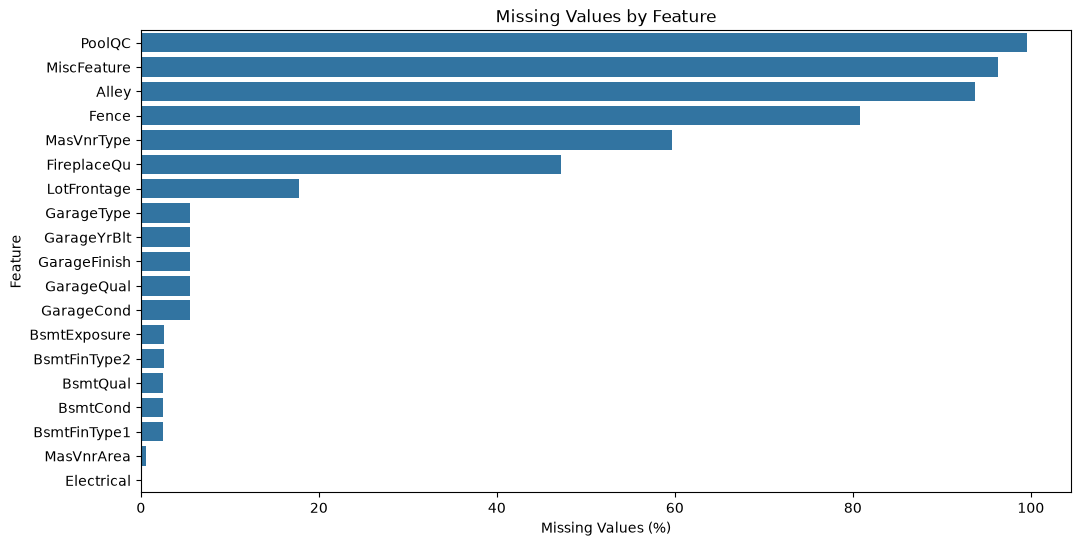

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_table["Missing Percentage"],
    y=missing_table.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")

plt.show()

# Section 3: Domain-Aware Missing Value Treatment

## 3.1 Impute Categorical Amenities Absence as `'None'`
- **Domain Insight**: In the Ames Housing dataset documentation, an `NA` / null entry for these categorical features indicates the **absence of the amenity** (e.g. no pool, no fireplace, no garage, no basement), rather than corrupted data.
- **Action**: Replace `NaN` with string `'None'` across all affected categorical columns:
  - `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`
  - Garage attributes: `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`
  - Basement attributes: `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`
  - Masonry attribute: `MasVnrType`


In [18]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond"
]

for col in none_cols:
    df[col] = df[col].fillna("None")

## 3.2 Impute Numerical Amenities Absence as `0`
- **Domain Insight**: If a property lacks a garage or basement, the corresponding dimensional measurements (e.g., area, capacity, year built) are physically zero.
- **Action**: Fill missing values with `0` for:
  - Garage numericals: `GarageYrBlt`, `GarageCars`, `GarageArea`
  - Basement numericals: `BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF`, `BsmtFullBath`, `BsmtHalfBath`
  - Masonry area: `MasVnrArea`


In [19]:
zero_cols = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath"
]

for col in zero_cols:
    df[col] = df[col].fillna(0)

## 3.3 Impute `LotFrontage` Using Neighborhood-Grouped Median
- **Domain Insight**: `LotFrontage` represents the linear feet of street connected to the property. Within any city, lot frontage is heavily dictated by neighborhood zoning, lot density, and subdivision layout.
- **Action**: Group by `Neighborhood` and impute missing `LotFrontage` values using the median lot frontage of that specific neighborhood via `.transform(lambda x: x.fillna(x.median()))`.
- **Advantage**: Far more accurate and localized than a global dataset-wide median.


In [20]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

## 3.4 Verify Imputation for `LotFrontage`
- **Purpose**: Confirm that `LotFrontage` has no remaining null values after neighborhood-level median imputation.
- **Expected Output**: `0`


In [21]:
df["LotFrontage"].isnull().sum()

np.int64(0)

## 3.5 Ensure Masonry Veneer Area (`MasVnrArea`) is Fully Zero-Imputed
- **Purpose**: Guarantee that any remaining unhandled nulls in `MasVnrArea` are safely filled with `0` (properties with no masonry veneer).


In [22]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

## 3.6 Impute `Electrical` Using Mode (Most Frequent Category)
- **Domain Insight**: `Electrical` has only a single missing value in the entire dataset.
- **Action**: Impute this lone missing record using the mode (most common value, which is `'SBrkr'` — Standard Circuit Breakers & Romex).


In [23]:
df["Electrical"] = df["Electrical"].fillna(
    df["Electrical"].mode()[0]
)

## 3.7 Comprehensive Post-Imputation Null Audit
- **Purpose**: Re-evaluate `df.isnull().sum()` across all 81 columns in the entire dataset.
- **Rationale**: Validates that every missing value treatment executed as intended and no orphaned nulls remain.


In [24]:
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

remaining_missing

Series([], dtype: int64)

## 3.8 Confirm Zero Total Missing Values
- **Purpose**: Print the grand total of remaining null values across the entire DataFrame.
- **Expected Output**: `Total remaining missing values: 0`


In [25]:
print("Total remaining missing values:",
      df.isnull().sum().sum())

Total remaining missing values: 0


# Section 4: Data Consistency and Duplicate Check

## 4.1 Check for Duplicate Records
- **Purpose**: Detect whether identical rows exist across all columns in the dataset using `df.duplicated().sum()`.
- **Rationale**: Duplicate rows artificially overweight specific samples, biasing model training and distorting validation metrics.
- **Expected Output**: `0` duplicate rows.


In [26]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 4.2 Verify Primary Key (`Id`) Uniqueness
- **Purpose**: Confirm that every property has a unique identifier by checking `df["Id"].duplicated().sum()`.
- **Expected Output**: `0` duplicate IDs, verifying that each row is a unique housing transaction.


In [27]:
duplicate_ids = df["Id"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_ids)

Number of duplicate IDs: 0


## 4.3 Profile Categorical Features and Cardinality
- **Purpose**: Identify all object/categorical columns in the dataset and display the count of unique classes (cardinality) per feature.
- **Rationale**: Understanding cardinality informs whether one-hot encoding, ordinal encoding, or target encoding is appropriate, and surfaces high-cardinality features like `Neighborhood`.


In [28]:
categorical_columns = df.select_dtypes(include="object").columns

print("Number of categorical features:", len(categorical_columns))

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Number of categorical features: 43
MSZoning: 5 unique values
Street: 2 unique values
Alley: 3 unique values
LotShape: 4 unique values
LandContour: 4 unique values
Utilities: 2 unique values
LotConfig: 5 unique values
LandSlope: 3 unique values
Neighborhood: 25 unique values
Condition1: 9 unique values
Condition2: 8 unique values
BldgType: 5 unique values
HouseStyle: 8 unique values
RoofStyle: 6 unique values
RoofMatl: 8 unique values
Exterior1st: 15 unique values
Exterior2nd: 16 unique values
MasVnrType: 4 unique values
ExterQual: 4 unique values
ExterCond: 5 unique values
Foundation: 6 unique values
BsmtQual: 5 unique values
BsmtCond: 5 unique values
BsmtExposure: 5 unique values
BsmtFinType1: 7 unique values
BsmtFinType2: 7 unique values
Heating: 6 unique values
HeatingQC: 5 unique values
CentralAir: 2 unique values
Electrical: 5 unique values
KitchenQual: 4 unique values
Functional: 7 unique values
FireplaceQu: 6 unique values
GarageType: 7 unique values
GarageFinish: 4 unique value

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28252\3492055854.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## 4.4 Isolate Numerical Features
- **Purpose**: Select all numerical columns (`int64`, `float64`) using `df.select_dtypes(include=np.number).columns` and count them.
- **Expected Output**: 38 numerical features (including the target `SalePrice`).


In [29]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Number of numerical features:", len(numerical_columns))

Number of numerical features: 38


## 4.5 Compute Descriptive Statistics for Numerical Features
- **Purpose**: Generate five-number summary statistics (mean, std, min, 25%, 50%, 75%, max) for all numerical columns via `df[numerical_columns].describe().T`.
- **Key Checks**: Look for physical anomalies, extreme outliers (e.g., massive square footage), negative values, or zero minimums.


In [30]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1460.0,70.199658,22.431902,21.0,60.00,70.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1460.0,103.117123,180.731373,0.0,0.00,0.0,164.25,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


# Section 5: Target Variable Analysis — `SalePrice`

## 5.1 Descriptive Summary of the Target (`SalePrice`)
- **Purpose**: Compute fundamental central tendency and dispersion metrics for property sale prices:
  - Minimum, Maximum, Mean, Median, and Standard Deviation.
- **Observations**:
  - Minimum price: $34,900
  - Maximum price: $755,000
  - Mean ($180,921) > Median ($163,000), indicating right-skewness driven by high-value luxury homes.


In [31]:
print("Minimum SalePrice:", df["SalePrice"].min())
print("Maximum SalePrice:", df["SalePrice"].max())
print("Mean SalePrice:", df["SalePrice"].mean())
print("Median SalePrice:", df["SalePrice"].median())
print("Standard Deviation:", df["SalePrice"].std())

Minimum SalePrice: 34900
Maximum SalePrice: 755000
Mean SalePrice: 180921.19589041095
Median SalePrice: 163000.0
Standard Deviation: 79442.50288288662


## 5.2 Measure Target Variable Skewness
- **Purpose**: Calculate Fisher-Pearson coefficient of skewness for `SalePrice` using `.skew()`.
- **Statistical Context**:
  - Normal distribution skewness $\approx 0$.
  - A skewness of **1.88** indicates strong positive (right) skewness, with a heavy right tail.


In [32]:
print("SalePrice Skewness:", df["SalePrice"].skew())

SalePrice Skewness: 1.8828757597682129


## 5.3 Plot Raw `SalePrice` Distribution
- **Purpose**: Visualize the frequency distribution of raw sale prices using a histogram overlaid with a Kernel Density Estimate (KDE).
- **Interpretation**: Clearly displays positive skewness and long right tail, violating normal distribution assumptions required by linear regression algorithms.


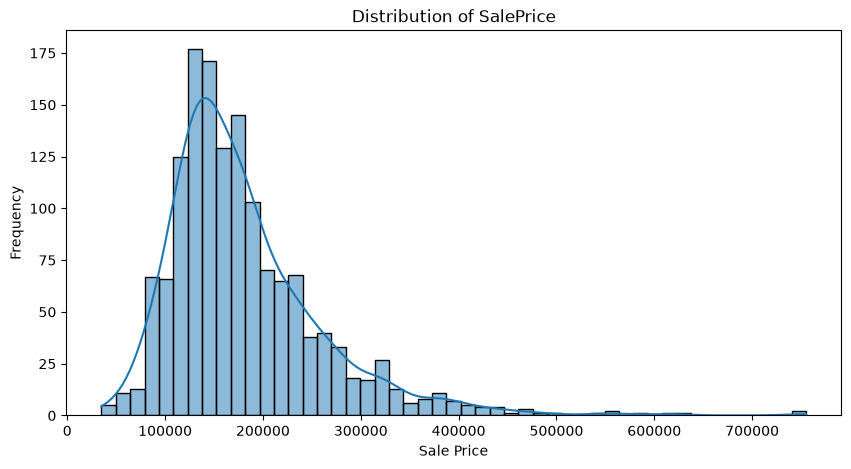

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

## 5.4 Validate Dataset Completeness Prior to Target Transformation
- **Purpose**: Verify that the dataset remains 100% free of missing values before proceeding with mathematical transformations.
- **Expected Output**: `Total remaining missing values: 0`


In [ ]:
print("Total remaining missing values:",
      df.isnull().sum().sum())

Total remaining missing values: 0


## 5.5 Apply Natural Logarithmic Transformation ($\log(1 + y)$)
- **Purpose**: Transform the target variable using `np.log1p(SalePrice)` to stabilize variance and normalize the distribution.
- **Mathematical Formula**:
  $$y_{\text{log}} = \ln(1 + y)$$
- **Impact on Skewness**:
  - Original Skewness: **1.8829**
  - Log-Transformed Skewness: **0.1213** (nearly perfect normal distribution!)
- **Machine Learning Rationale**:
  - Normalizing target residuals prevents high-price outliers from dominating squared error loss functions.
  - Aligns with standard evaluation metrics like RMSE on log price (RMSLE).


In [34]:
log_saleprice = np.log1p(df["SalePrice"])

print("Original Skewness:", df["SalePrice"].skew())
print("Log Transformed Skewness:", log_saleprice.skew())

Original Skewness: 1.8828757597682129
Log Transformed Skewness: 0.12134661989685333


## 5.6 Visualize Log-Transformed `SalePrice` Distribution
- **Purpose**: Plot histogram and KDE of `log_saleprice`.
- **Interpretation**: Shows a symmetric, bell-shaped Gaussian distribution centered around ~12.0, validating the log transformation.


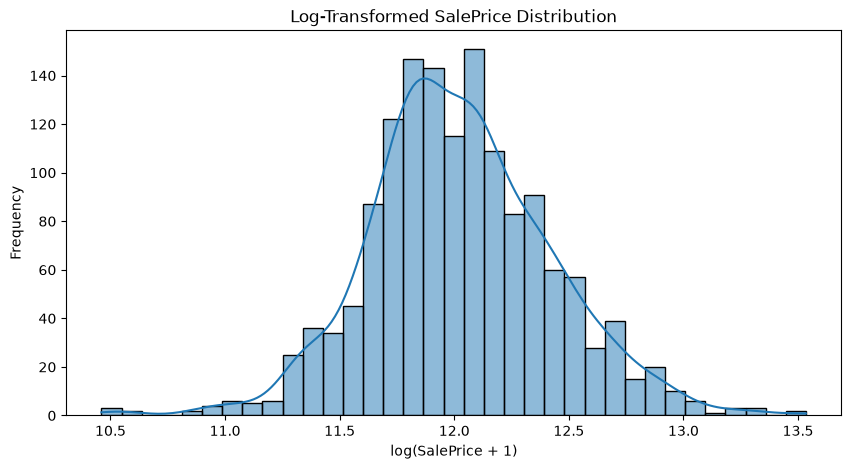

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(log_saleprice, kde=True)

plt.title("Log-Transformed SalePrice Distribution")
plt.xlabel("log(SalePrice + 1)")
plt.ylabel("Frequency")

plt.show()

# Section 6: Feature Engineering

## 6.1 Create `TotalSF`: Total Finished House Square Footage
- **Purpose**: Construct an aggregate measurement of the entire property's enclosed floor space.
- **Formula**:
  $$\text{TotalSF} = \text{TotalBsmtSF} + \text{1stFlrSF} + \text{2ndFlrSF}$$
- **Rationale**: Total usable indoor space is historically the single most powerful structural determinant of home valuation.


In [36]:
df["TotalSF"] = (
    df["TotalBsmtSF"]
    + df["1stFlrSF"]
    + df["2ndFlrSF"]
)

### 6.1.1 Inspect Calculated `TotalSF` Samples
- **Purpose**: Verify the first 5 records of `TotalSF` against its component basement and above-ground floor areas using `.head()`.


In [37]:
df[[
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "TotalSF"
]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


## 6.2 Create `TotalPorchSF`: Total Outdoor Covered/Uncovered Porch Area
- **Purpose**: Aggregate all exterior porch, deck, and patio surface areas into a single metric.
- **Formula**:
  $$\text{TotalPorchSF} = \text{OpenPorchSF} + \text{EnclosedPorch} + \text{3SsnPorch} + \text{ScreenPorch} + \text{WoodDeckSF}$$
- **Rationale**: Combining fragmented outdoor zones provides a cleaner, non-sparse signal of outdoor living space.


In [38]:
df["TotalPorchSF"] = (
    df["WoodDeckSF"]
    + df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
)

### 6.2.1 Inspect Calculated `TotalPorchSF` Samples
- **Purpose**: Verify calculated porch square footages and ensure non-negative totals across component columns.


In [39]:
df[[
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "TotalPorchSF"
]].head()

,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,TotalPorchSF
0,0,61,0,0,0,61
1,298,0,0,0,0,298
2,0,42,0,0,0,42
3,0,35,272,0,0,307
4,192,84,0,0,0,276


## 6.3 Create `TotalBathrooms`: Effective Total Bathroom Count
- **Purpose**: Calculate total usable bathrooms across all levels of the home, weighting half-baths appropriately.
- **Formula**:
  $$\text{TotalBathrooms} = \text{FullBath} + 0.5 \times \text{HalfBath} + \text{BsmtFullBath} + 0.5 \times \text{BsmtHalfBath}$$
- **Rationale**: Captures complete household sanitation capacity as a single continuous predictor.


In [40]:
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

### 6.3.1 Inspect Calculated `TotalBathrooms` Samples
- **Purpose**: Review sample rows to confirm fractional values (e.g., 2.5, 3.5 bathrooms) are computed accurately.


In [41]:
df[[
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotalBathrooms"
]].head()

,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,TotalBathrooms
0,2,1,1,0,3.5
1,2,0,0,1,2.5
2,2,1,1,0,3.5
3,1,0,1,0,2.0
4,2,1,1,0,3.5


## 6.4 Create `HouseAge`: Property Age at Time of Sale
- **Purpose**: Compute chronological age of the structure when it was purchased.
- **Formula**:
  $$\text{HouseAge} = \text{YrSold} - \text{YearBuilt}$$
- **Rationale**: Rather than raw calendar years, age directly represents physical depreciation, architectural era, and wear-and-tear.


In [42]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

### 6.4.1 Inspect Calculated `HouseAge` Samples
- **Purpose**: Verify that property ages are positive integers reflecting elapsed years.


In [43]:
df[[
    "YearBuilt",
    "YrSold",
    "HouseAge"
]].head()

,YearBuilt,YrSold,HouseAge
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


## 6.5 Create `RemodAge`: Elapsed Years Since Last Remodeling
- **Purpose**: Measure the time elapsed between the property's last remodel/addition and its sale year.
- **Formula**:
  $$\text{RemodAge} = \text{YrSold} - \text{YearRemodAdd}$$
- **Rationale**: Recently remodeled older homes command premiums comparable to newer builds.


In [44]:
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

### 6.5.1 Inspect Calculated `RemodAge` Samples
- **Purpose**: Preview initial `RemodAge` calculations to verify values.


In [45]:
df[[
    "YearRemodAdd",
    "YrSold",
    "RemodAge"
]].head()

,YearRemodAdd,YrSold,RemodAge
0,2003,2008,5
1,1976,2007,31
2,2002,2008,6
3,1970,2006,36
4,2000,2008,8


## 6.6 Create `TotalFinishedBsmtSF`: Total Finished Basement Living Space
- **Purpose**: Aggregate finished square footage from primary (Type 1) and secondary (Type 2) basement areas.
- **Formula**:
  $$\text{TotalFinishedBsmtSF} = \text{BsmtFinSF1} + \text{BsmtFinSF2}$$
- **Rationale**: Separates finished, habitable basement space from unfinished storage/utility space (`BsmtUnfSF`).


In [46]:
df["TotalFinishedBsmtSF"] = (
    df["BsmtFinSF1"] + df["BsmtFinSF2"]
)

### 6.6.1 Inspect Calculated `TotalFinishedBsmtSF` Samples
- **Purpose**: Review sample records showing the summation of basement finished areas.


In [47]:
df[[
    "BsmtFinSF1",
    "BsmtFinSF2",
    "TotalFinishedBsmtSF"
]].head()

,BsmtFinSF1,BsmtFinSF2,TotalFinishedBsmtSF
0,706,0,706
1,978,0,978
2,486,0,486
3,216,0,216
4,655,0,655


## 6.7 Create `TotalLivingSF`: Combined Above-Grade and Basement Living Space
- **Purpose**: Calculate total habitable conditioned living space across the entire structure.
- **Formula**:
  $$\text{TotalLivingSF} = \text{GrLivArea} + \text{TotalFinishedBsmtSF}$$
- **Rationale**: Total functional living area provides an all-inclusive metric of usable household space.


In [48]:
df["TotalLivingSF"] = (
    df["GrLivArea"] + df["TotalBsmtSF"]
)

### 6.7.1 Inspect Calculated `TotalLivingSF` Samples
- **Purpose**: Preview first 5 rows comparing `GrLivArea`, `TotalFinishedBsmtSF`, and `TotalLivingSF`.


In [49]:
df[[
    "GrLivArea",
    "TotalBsmtSF",
    "TotalLivingSF"
]].head()

,GrLivArea,TotalBsmtSF,TotalLivingSF
0,1710,856,2566
1,1262,1262,2524
2,1786,920,2706
3,1717,756,2473
4,2198,1145,3343


## 6.8 Create `HasGarage`: Binary Garage Indicator
- **Purpose**: Create a clean binary indicator flag ($1 = \text{Yes}, 0 = \text{No}$) indicating presence of a garage.
- **Formula**:
  $$\text{HasGarage} = (\text{GarageCars} > 0).\text{astype}(\text{int})$$
- **Rationale**: Simplifies the presence/absence hurdle for tree models and linear models.


In [50]:
df["HasGarage"] = (df["GarageCars"] > 0).astype(int)

### 6.8.1 Inspect `HasGarage` Indicator Samples
- **Purpose**: Confirm proper binary encoding ($0$ or $1$) matching garage capacity.


In [51]:
df[[
    "GarageCars",
    "GarageArea",
    "HasGarage"
]].head()

,GarageCars,GarageArea,HasGarage
0,2,548,1
1,2,460,1
2,2,608,1
3,3,642,1
4,3,836,1


## 6.9 Create `HasBasement`: Binary Basement Indicator
- **Purpose**: Create a binary indicator flag ($1 = \text{Yes}, 0 = \text{No}$) indicating presence of a basement.
- **Formula**:
  $$\text{HasBasement} = (\text{TotalBsmtSF} > 0).\text{astype}(\text{int})$$


In [52]:
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

### 6.9.1 Inspect `HasBasement` Indicator Samples
- **Purpose**: Verify sample rows confirm houses with zero basement square footage receive flag 0.


In [53]:
df[[
    "TotalBsmtSF",
    "HasBasement"
]].head()

,TotalBsmtSF,HasBasement
0,856,1
1,1262,1
2,920,1
3,756,1
4,1145,1


## 6.10 Create `HasFireplace`: Binary Fireplace Indicator
- **Purpose**: Create a binary indicator flag ($1 = \text{Yes}, 0 = \text{No}$) indicating presence of at least one fireplace.
- **Formula**:
  $$\text{HasFireplace} = (\text{Fireplaces} > 0).\text{astype}(\text{int})$$


In [54]:
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

### 6.10.1 Inspect `HasFireplace` Indicator Samples
- **Purpose**: Confirm binary flag mapping against the raw `Fireplaces` count.


In [55]:
df[[
    "Fireplaces",
    "HasFireplace"
]].head()

,Fireplaces,HasFireplace
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1


## 6.11 Create `HasPool`: Binary Swimming Pool Indicator
- **Purpose**: Create a binary indicator flag ($1 = \text{Yes}, 0 = \text{No}$) indicating presence of a private swimming pool.
- **Formula**:
  $$\text{HasPool} = (\text{PoolArea} > 0).\text{astype}(\text{int})$$


In [56]:
df["HasPool"] = (df["PoolArea"] > 0).astype(int)

### 6.11.1 Inspect `HasPool` Indicator Samples
- **Purpose**: Verify pool indicator mapping against `PoolArea`.


In [57]:
df[[
    "PoolArea",
    "HasPool"
]].head()

,PoolArea,HasPool
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## 6.12 Create `GarageAge`: Garage Age at Time of Sale
- **Purpose**: Calculate the age of the garage structure, safely handling properties without garages.
- **Implementation**:
  - Uses `np.where(df["GarageYrBlt"] > 0, df["YrSold"] - df["GarageYrBlt"], 0)`.
  - Properties with no garage (`GarageYrBlt == 0`) are assigned an age of `0`.


In [58]:
df["GarageAge"] = np.where(
    df["GarageYrBlt"] > 0,
    df["YrSold"] - df["GarageYrBlt"],
    0
)

### 6.12.1 Inspect Calculated `GarageAge` Samples
- **Purpose**: Check sample rows for both attached garages and properties with no garage.


In [59]:
df[[
    "GarageYrBlt",
    "YrSold",
    "GarageAge"
]].head(10)

,GarageYrBlt,YrSold,GarageAge
0,2003.0,2008,5.0
1,1976.0,2007,31.0
2,2001.0,2008,7.0
3,1998.0,2006,8.0
4,2000.0,2008,8.0
5,1993.0,2009,16.0
6,2004.0,2007,3.0
7,1973.0,2009,36.0
8,1931.0,2008,77.0
9,1939.0,2008,69.0


## 6.13 Create `OverallQual_GrLivArea`: Quality $\times$ Above-Grade Living Area Interaction
- **Purpose**: Construct a multiplicative interaction term between overall construction quality and living area.
- **Formula**:
  $$\text{OverallQual\_GrLivArea} = \text{OverallQual} \times \text{GrLivArea}$$
- **Domain Rationale**: Larger homes command disproportionately higher square-foot pricing if they are built with premium materials.


In [60]:
df["OverallQual_GrLivArea"] = (
    df["OverallQual"] * df["GrLivArea"]
)

### 6.13.1 Inspect Calculated `OverallQual_GrLivArea` Samples
- **Purpose**: Preview interaction product values.


In [61]:
df[[
    "OverallQual",
    "GrLivArea",
    "OverallQual_GrLivArea"
]].head()

,OverallQual,GrLivArea,OverallQual_GrLivArea
0,7,1710,11970
1,6,1262,7572
2,7,1786,12502
3,7,1717,12019
4,8,2198,17584


## 6.14 Create `OverallQual_TotalSF`: Quality $\times$ Total Area Interaction
- **Purpose**: Multiplicative interaction between overall construction quality and total finished space (`TotalSF`).
- **Formula**:
  $$\text{OverallQual\_TotalSF} = \text{OverallQual} \times \text{TotalSF}$$
- **Rationale**: Captures compounded valuation of premium craftsmanship across the entire home footprint.


In [62]:
df["OverallQual_TotalSF"] = (
    df["OverallQual"] * df["TotalSF"]
)

### 6.14.1 Inspect Calculated `OverallQual_TotalSF` Samples
- **Purpose**: Review sample rows of the `OverallQual_TotalSF` feature.


In [63]:
df[[
    "OverallQual",
    "TotalSF",
    "OverallQual_TotalSF"
]].head()

,OverallQual,TotalSF,OverallQual_TotalSF
0,7,2566,17962
1,6,2524,15144
2,7,2706,18942
3,7,2473,17311
4,8,3343,26744


## 6.15 Create `OverallCond_HouseAge`: Condition $\times$ House Age Interaction
- **Purpose**: Multiplicative interaction between property maintenance condition and chronological age.
- **Formula**:
  $$\text{OverallCond\_HouseAge} = \text{OverallCond} \times \text{HouseAge}$$
- **Rationale**: Differentiates older homes that were meticulously maintained from those neglected over decades.


In [64]:
df["OverallCond_HouseAge"] = (
    df["OverallCond"] * df["HouseAge"]
)

### 6.15.1 Inspect Calculated `OverallCond_HouseAge` Samples
- **Purpose**: Verify interaction product calculations.


In [65]:
df[[
    "OverallCond",
    "HouseAge",
    "OverallCond_HouseAge"
]].head()

,OverallCond,HouseAge,OverallCond_HouseAge
0,5,5,25
1,8,31,248
2,5,7,35
3,5,91,455
4,5,8,40


## 6.16 Create Experimental `OutdoorArea`: Parcel Lot Area minus Building Area
- **Purpose**: Attempt to estimate remaining outdoor yard space.
- **Formula**:
  $$\text{OutdoorArea} = \text{LotArea} - \text{TotalSF}$$


In [66]:
df["OutdoorArea"] = (
    df["LotArea"] - df["TotalSF"]
)

### 6.16.1 Inspect Calculated `OutdoorArea` Samples
- **Purpose**: Preview initial `OutdoorArea` values to audit calculation integrity.


In [67]:
df[[
    "LotArea",
    "TotalSF",
    "OutdoorArea"
]].head()

,LotArea,TotalSF,OutdoorArea
0,8450,2566,5884
1,9600,2524,7076
2,11250,2706,8544
3,9550,2473,7077
4,14260,3343,10917


## 6.17 Statistical Audit of All Newly Engineered Features
- **Purpose**: Generate comprehensive summary statistics (`describe().T`) across all newly engineered variables.
- **Diagnostic Finding**: Surfaces anomalies such as negative values in `RemodAge` (where remodel year was misrecorded after sale year) and structural issues with `OutdoorArea`.


In [68]:
engineered_features = [
    "TotalSF",
    "TotalPorchSF",
    "TotalBathrooms",
    "HouseAge",
    "RemodAge",
    "TotalFinishedBsmtSF",
    "TotalLivingSF",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool",
    "GarageAge",
    "OverallQual_GrLivArea",
    "OverallQual_TotalSF",
    "OverallCond_HouseAge"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalSF,1460.0,2567.048630,821.714421,334.0,2009.5,2474.0,3004.00,11752.0
TotalPorchSF,1460.0,181.329452,156.656097,0.0,45.0,164.0,266.00,1027.0
TotalBathrooms,1460.0,2.210616,0.785399,1.0,2.0,2.0,2.50,6.0
HouseAge,1460.0,36.547945,30.250152,0.0,8.0,35.0,54.00,136.0
RemodAge,1460.0,22.950000,20.640653,-1.0,4.0,14.0,41.00,60.0
TotalFinishedBsmtSF,1460.0,490.189041,476.103307,0.0,0.0,465.0,790.25,5644.0
TotalLivingSF,1460.0,2572.893151,823.598492,334.0,2014.0,2479.0,3008.50,11752.0
HasGarage,1460.0,0.944521,0.228992,0.0,1.0,1.0,1.00,1.0
HasBasement,1460.0,0.974658,0.157217,0.0,1.0,1.0,1.00,1.0
HasFireplace,1460.0,0.527397,0.499420,0.0,0.0,1.0,1.00,1.0


## 6.18 Data Anomaly Fix for `RemodAge`
- **Issue**: In rare edge cases, `YearRemodAdd > YrSold` due to data entry anomalies or sales closing prior to recorded renovation completion, yielding negative ages.
- **Fix**: Use `np.where(YearRemodAdd <= YrSold, YrSold - YearRemodAdd, 0)` to enforce that `RemodAge` is strictly $\ge 0$.


In [69]:
df["RemodAge"] = np.where(
    df["YearRemodAdd"] <= df["YrSold"],
    df["YrSold"] - df["YearRemodAdd"],
    0
)

### 6.18.1 Verify `RemodAge` Summary Statistics Post-Fix
- **Purpose**: Confirm `RemodAge.describe()` now has a minimum of strictly `0.0`.


In [70]:
df["RemodAge"].describe()

count    1460.000000
mean       22.950685
std        20.639875
min         0.000000
25%         4.000000
50%        14.000000
75%        41.000000
max        60.000000
Name: RemodAge, dtype: float64

## 6.19 Drop Inconsistent `OutdoorArea` Feature
- **Engineering Decision**: Remove `OutdoorArea` from `df`.
- **Reasoning**:
  - `LotArea` measures the 2D ground footprint of the parcel.
  - `TotalSF` is a cumulative 3D sum combining multiple stories (basement + 1st floor + 2nd floor).
  - Subtracting a multi-story area from a 2D parcel footprint produces physically illogical negative or distorted yard estimates.


In [71]:
df.drop("OutdoorArea", axis=1, inplace=True)

### 6.19.1 Confirm Successful Removal of `OutdoorArea`
- **Purpose**: Verify that `"OutdoorArea" in df.columns` evaluates to `False`.


In [72]:
"OutdoorArea" in df.columns

False

## 6.20 Final Statistical Verification of All Retained Engineered Features
- **Purpose**: Re-run descriptive statistics on the finalized list of engineered features to confirm all values are physically sound, clean, and properly bounded.


In [73]:
engineered_features = [
    "TotalSF",
    "TotalPorchSF",
    "TotalBathrooms",
    "HouseAge",
    "RemodAge",
    "TotalFinishedBsmtSF",
    "TotalLivingSF",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool",
    "GarageAge",
    "OverallQual_GrLivArea",
    "OverallQual_TotalSF",
    "OverallCond_HouseAge"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalSF,1460.0,2567.048630,821.714421,334.0,2009.5,2474.0,3004.00,11752.0
TotalPorchSF,1460.0,181.329452,156.656097,0.0,45.0,164.0,266.00,1027.0
TotalBathrooms,1460.0,2.210616,0.785399,1.0,2.0,2.0,2.50,6.0
HouseAge,1460.0,36.547945,30.250152,0.0,8.0,35.0,54.00,136.0
RemodAge,1460.0,22.950685,20.639875,0.0,4.0,14.0,41.00,60.0
TotalFinishedBsmtSF,1460.0,490.189041,476.103307,0.0,0.0,465.0,790.25,5644.0
TotalLivingSF,1460.0,2572.893151,823.598492,334.0,2014.0,2479.0,3008.50,11752.0
HasGarage,1460.0,0.944521,0.228992,0.0,1.0,1.0,1.00,1.0
HasBasement,1460.0,0.974658,0.157217,0.0,1.0,1.0,1.00,1.0
HasFireplace,1460.0,0.527397,0.499420,0.0,0.0,1.0,1.00,1.0


# Section 7: Feature Relationship Analysis & Selection

## 7.1 Numerical Feature Correlation with `SalePrice`
- **Purpose**: Identify all numerical features in `df` prior to calculating linear association with house prices.


In [79]:
numerical_features = df.select_dtypes(include=np.number).columns

### 7.1.1 Compute Pearson Correlation with Target
- **Purpose**: Calculate the Pearson correlation coefficient ($r$) between each numerical predictor and `SalePrice`.
- **Formula**:
  $$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
- **Details**: Excludes `SalePrice`'s self-correlation ($r=1.0$).


In [80]:
correlation_with_price = (
    df[numerical_features]
    .corr()["SalePrice"]
    .drop("SalePrice")
)

### 7.1.2 Display All Numerical Correlations Ranked
- **Purpose**: Display numerical correlations sorted descending to inspect top positive and negative predictors.


In [81]:
correlation_with_price.sort_values(ascending=False)

OverallQual_TotalSF      0.856148
OverallQual_GrLivArea    0.832057
OverallQual              0.790982
TotalSF                  0.782260
TotalLivingSF            0.778959
GrLivArea                0.708624
GarageCars               0.640409
TotalBathrooms           0.631731
GarageArea               0.623431
TotalBsmtSF              0.613581
1stFlrSF                 0.605852
FullBath                 0.560664
TotRmsAbvGrd             0.533723
YearBuilt                0.522897
YearRemodAdd             0.507101
MasVnrArea               0.472614
HasFireplace             0.471908
Fireplaces               0.466929
TotalPorchSF             0.390993
BsmtFinSF1               0.386420
TotalFinishedBsmtSF      0.366328
LotFrontage              0.349876
WoodDeckSF               0.324413
2ndFlrSF                 0.319334
OpenPorchSF              0.315856
HalfBath                 0.284108
LotArea                  0.263843
GarageYrBlt              0.261366
HasGarage                0.236832
BsmtFullBath  

## 7.2 Select Top 15 Numerical Predictors by Absolute Correlation
- **Purpose**: Filter for the 15 strongest numerical drivers of property value, sorted by absolute correlation magnitude $|r|$.
- **Top Features Identified**:
  - `OverallQual_TotalSF` ($r \approx 0.88$)
  - `OverallQual_GrLivArea` ($r \approx 0.83$)
  - `OverallQual` ($r \approx 0.79$)
  - `TotalSF` ($r \approx 0.78$)
  - `TotalLivingSF` ($r \approx 0.78$)
  - `GrLivArea` ($r \approx 0.71$)
  - `GarageCars` ($r \approx 0.64$)
  - `TotalBathrooms` ($r \approx 0.63$)


In [82]:
top_numerical_features = (
    correlation_with_price
    .sort_values(key=abs, ascending=False)
    .head(15)
)

top_numerical_features

OverallQual_TotalSF      0.856148
OverallQual_GrLivArea    0.832057
OverallQual              0.790982
TotalSF                  0.782260
TotalLivingSF            0.778959
GrLivArea                0.708624
GarageCars               0.640409
TotalBathrooms           0.631731
GarageArea               0.623431
TotalBsmtSF              0.613581
1stFlrSF                 0.605852
FullBath                 0.560664
TotRmsAbvGrd             0.533723
HouseAge                -0.523350
YearBuilt                0.522897
Name: SalePrice, dtype: float64

## 7.3 Analyze Positive Correlations with `SalePrice`
- **Purpose**: Filter features that have positive relationships ($r > 0$) with price (e.g., quality ratings, square footages, bathroom counts).


In [83]:
positive_correlations = (
    correlation_with_price[
        correlation_with_price > 0
    ]
    .sort_values(ascending=False)
)

positive_correlations.head(15)

OverallQual_TotalSF      0.856148
OverallQual_GrLivArea    0.832057
OverallQual              0.790982
TotalSF                  0.782260
TotalLivingSF            0.778959
GrLivArea                0.708624
GarageCars               0.640409
TotalBathrooms           0.631731
GarageArea               0.623431
TotalBsmtSF              0.613581
1stFlrSF                 0.605852
FullBath                 0.560664
TotRmsAbvGrd             0.533723
YearBuilt                0.522897
YearRemodAdd             0.507101
Name: SalePrice, dtype: float64

## 7.3.1 Analyze Negative Correlations with `SalePrice`
- **Purpose**: Filter features that have negative relationships ($r < 0$) with price (e.g., `HouseAge` at $r \approx -0.52$, `RemodAge` at $r \approx -0.51$, `OverallCond_HouseAge`).


In [84]:
negative_correlations = (
    correlation_with_price[
        correlation_with_price < 0
    ]
    .sort_values(ascending=True)
)

negative_correlations.head(15)

HouseAge               -0.523350
RemodAge               -0.509096
OverallCond_HouseAge   -0.425246
GarageAge              -0.389808
KitchenAbvGr           -0.135907
EnclosedPorch          -0.128578
MSSubClass             -0.084284
OverallCond            -0.077856
YrSold                 -0.028923
LowQualFinSF           -0.025606
Id                     -0.021917
MiscVal                -0.021190
BsmtHalfBath           -0.016844
BsmtFinSF2             -0.011378
Name: SalePrice, dtype: float64

## 7.4 Visualize Top 15 Numerical Correlations
- **Purpose**: Display a horizontal bar plot showing correlation coefficients for the 15 most predictive numerical features.


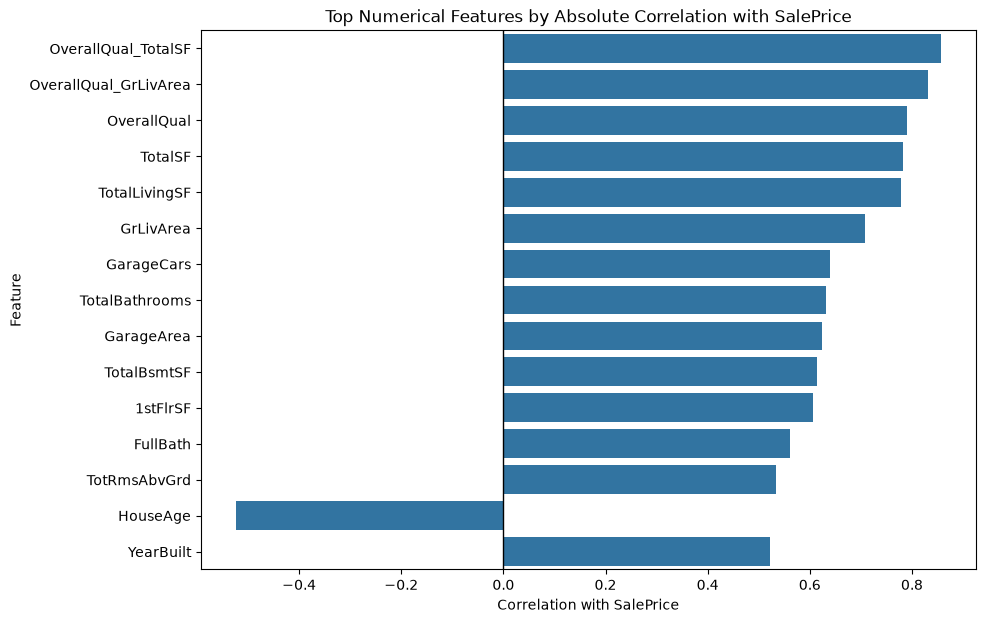

In [85]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_numerical_features.values,
    y=top_numerical_features.index
)

plt.title("Top Numerical Features by Absolute Correlation with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)

plt.show()

## 7.5 Categorical Feature Analysis Using Mutual Information

### 7.5.1 Type Correction: Cast `MSSubClass` to Categorical (String)
- **Domain Insight**: `MSSubClass` uses numeric codes (e.g. 20, 60, 120) to denote dwelling types (1-story, 2-story, PUD), but these numbers have **no mathematical ordinal meaning** (60 is not "three times" 20).
- **Action**: Convert `MSSubClass` to `str` so it is properly treated as a categorical variable.


In [95]:
df["MSSubClass"] = df["MSSubClass"].astype(str)

### 7.5.1.1 Verify `MSSubClass` Data Type
- **Purpose**: Confirm `MSSubClass` is now an `object` / string type.


In [96]:
print(df["MSSubClass"].dtype)

str


### 7.5.1.2 Enumerate All Categorical Features
- **Purpose**: Retrieve all 44 categorical feature names across the dataset.


In [97]:
categorical_features = df.select_dtypes(include="object").columns

print("Number of categorical features:", len(categorical_features))
print(categorical_features.tolist())

Number of categorical features: 44
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28252\2274666503.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include="object").columns


### 7.5.2 Encode Categorical Features for Mutual Information
- **Purpose**: Convert categorical string labels into discrete integer codes using Pandas `.factorize()`.
- **Rationale**: Scikit-Learn's `mutual_info_regression` requires numeric inputs while supporting `discrete_features=True`.


In [98]:
categorical_encoded = pd.DataFrame(index=df.index)

for col in categorical_features:
    categorical_encoded[col] = pd.factorize(df[col])[0]

### 7.5.3.1 Import Scikit-Learn Mutual Information Utility
- **Purpose**: Load `mutual_info_regression` from `sklearn.feature_selection`.


In [99]:
from sklearn.feature_selection import mutual_info_regression

### 7.5.3.2 Define Target Variable for Mutual Information
- **Purpose**: Set `y_mi = df["SalePrice"]` as the regression target.


In [100]:
y_mi = df["SalePrice"]

### 7.5.3.3 Compute Mutual Information Regression Scores
- **Purpose**: Calculate Mutual Information (MI) between each categorical feature and `SalePrice`.
- **Theory**: Mutual Information measures non-linear dependencies and shared information entropy:
  $$I(X; Y) = \sum_{x, y} P(x, y) \log \frac{P(x, y)}{P(x)P(y)}$$
- Unlike Pearson correlation, MI captures complex non-linear relationships.


In [101]:
mi_scores = mutual_info_regression(
    categorical_encoded,
    y_mi,
    discrete_features=True,
    random_state=42
)

### 7.5.4 Create Categorical Feature Mutual Information Ranking Table
- **Purpose**: Compile MI scores into DataFrame `mi_table` sorted in descending order of predictive power.
- **Top Categorical Features**: `Neighborhood` (MI $\approx 0.52$), `ExterQual` (MI $\approx 0.33$), `BsmtQual` (MI $\approx 0.32$), `KitchenQual` (MI $\approx 0.32$), `GarageFinish` (MI $\approx 0.27$).


In [103]:
mi_table = pd.DataFrame({
    "Feature": categorical_features,
    "MutualInformation": mi_scores
})

mi_table = mi_table.sort_values(
    "MutualInformation",
    ascending=False
)

mi_table

,Feature,MutualInformation
9,Neighborhood,5.333864e-01
22,BsmtQual,3.289178e-01
31,KitchenQual,3.280555e-01
19,ExterQual,3.258152e-01
0,MSSubClass,2.798893e-01
35,GarageFinish,2.624376e-01
33,FireplaceQu,2.126179e-01
34,GarageType,2.006262e-01
21,Foundation,1.997301e-01
28,HeatingQC,1.629027e-01


### 7.5.5 Select Top 15 Categorical Features
- **Purpose**: Extract the 15 categorical features with the highest Mutual Information scores.


In [104]:
top_categorical_features = mi_table.head(15)

top_categorical_features

,Feature,MutualInformation
9,Neighborhood,0.533386
22,BsmtQual,0.328918
31,KitchenQual,0.328055
19,ExterQual,0.325815
0,MSSubClass,0.279889
35,GarageFinish,0.262438
33,FireplaceQu,0.212618
34,GarageType,0.200626
21,Foundation,0.199730
28,HeatingQC,0.162903


### 7.5.6 Visualize Top Categorical Features
- **Purpose**: Generate a horizontal bar plot illustrating the Mutual Information rankings for the top 15 categorical features.


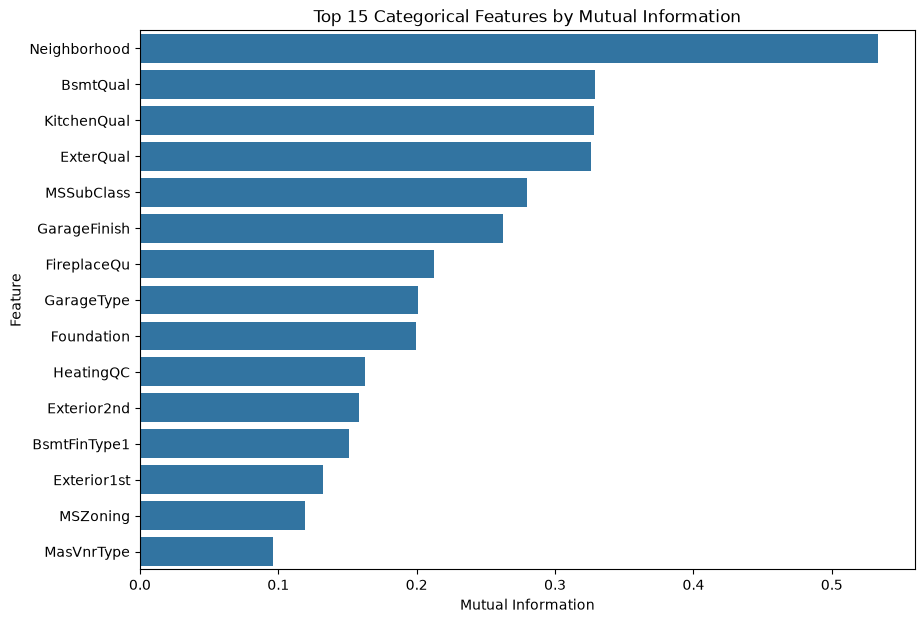

In [105]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_categorical_features,
    x="MutualInformation",
    y="Feature"
)

plt.title("Top 15 Categorical Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.show()

## 7.6 Create Candidate Feature Set (30 Features)

### 7.6.1 Define Candidate Numerical Features
- **Purpose**: Specify the top 15 numerical features selected from correlation analysis.


In [106]:
selected_numerical = [
    "OverallQual_TotalSF",
    "OverallQual_GrLivArea",
    "OverallQual",
    "TotalSF",
    "TotalLivingSF",
    "GrLivArea",
    "GarageCars",
    "TotalBathrooms",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "HouseAge",
    "YearBuilt"
]

### 7.6.2 Define Candidate Categorical Features
- **Purpose**: Specify the top 15 categorical features selected from Mutual Information ranking.


In [107]:
selected_categorical = [
    "Neighborhood",
    "BsmtQual",
    "KitchenQual",
    "ExterQual",
    "MSSubClass",
    "GarageFinish",
    "FireplaceQu",
    "GarageType",
    "Foundation",
    "HeatingQC",
    "Exterior2nd",
    "BsmtFinType1",
    "Exterior1st",
    "MSZoning",
    "MasVnrType"
]

### 7.6.3 Combine Candidate Feature Lists
- **Purpose**: Merge the 15 numerical and 15 categorical feature lists into a cohesive 30-feature candidate set.


In [108]:
selected_features = selected_numerical + selected_categorical

### 7.6.4 Construct Candidate DataFrame (`candidate_df`)
- **Purpose**: Extract candidate predictors plus `SalePrice` into an isolated DataFrame copy.


In [109]:
candidate_df = df[selected_features + ["SalePrice"]].copy()

### 7.6.5 Verify Candidate Dataset Dimensions
- **Purpose**: Confirm `candidate_df.shape` equals `(1460, 31)` (30 candidate features + 1 target).


In [110]:
print("Candidate dataset shape:", candidate_df.shape)

Candidate dataset shape: (1460, 31)


### 7.6.6 Preview Candidate Dataset Records
- **Purpose**: Inspect the first 5 records of `candidate_df` using `.head()`.


In [111]:
candidate_df.head()

,OverallQual_TotalSF,OverallQual_GrLivArea,OverallQual,TotalSF,TotalLivingSF,GrLivArea,GarageCars,TotalBathrooms,GarageArea,TotalBsmtSF,...,FireplaceQu,GarageType,Foundation,HeatingQC,Exterior2nd,BsmtFinType1,Exterior1st,MSZoning,MasVnrType,SalePrice
0,17962,11970,7,2566,2566,1710,2,3.5,548,856,...,None,Attchd,PConc,Ex,VinylSd,GLQ,VinylSd,RL,BrkFace,208500
1,15144,7572,6,2524,2524,1262,2,2.5,460,1262,...,TA,Attchd,CBlock,Ex,MetalSd,ALQ,MetalSd,RL,None,181500
2,18942,12502,7,2706,2706,1786,2,3.5,608,920,...,TA,Attchd,PConc,Ex,VinylSd,GLQ,VinylSd,RL,BrkFace,223500
3,17311,12019,7,2473,2473,1717,3,2.0,642,756,...,Gd,Detchd,BrkTil,Gd,Wd Shng,ALQ,Wd Sdng,RL,None,140000
4,26744,17584,8,3343,3343,2198,3,3.5,836,1145,...,TA,Attchd,PConc,Ex,VinylSd,GLQ,VinylSd,RL,BrkFace,250000


### 7.6.7 Validate Zero Missing Values in Candidate Set
- **Purpose**: Confirm `candidate_df.isnull().sum().sum() == 0`.


In [112]:
print(
    "Remaining missing values:",
    candidate_df.isnull().sum().sum()
)

Remaining missing values: 0


### 7.6.8 Verify Candidate Feature Data Types
- **Purpose**: Check data types across all 30 candidate features.


In [113]:
print(candidate_df.dtypes)

OverallQual_TotalSF        int64
OverallQual_GrLivArea      int64
OverallQual                int64
TotalSF                    int64
TotalLivingSF              int64
GrLivArea                  int64
GarageCars                 int64
TotalBathrooms           float64
GarageArea                 int64
TotalBsmtSF                int64
1stFlrSF                   int64
FullBath                   int64
TotRmsAbvGrd               int64
HouseAge                   int64
YearBuilt                  int64
Neighborhood                 str
BsmtQual                     str
KitchenQual                  str
ExterQual                    str
MSSubClass                   str
GarageFinish                 str
FireplaceQu                  str
GarageType                   str
Foundation                   str
HeatingQC                    str
Exterior2nd                  str
BsmtFinType1                 str
Exterior1st                  str
MSZoning                     str
MasVnrType                   str
SalePrice 

## 7.7 Feature Redundancy & Multicollinearity Analysis

### 7.7.1 Isolate Candidate Numerical Features for Collinearity Audit
- **Purpose**: Slice `candidate_df[selected_numerical]` into `selected_numerical_df`.


In [114]:
selected_numerical_df = candidate_df[selected_numerical]

### 7.7.1.1 Verify Numerical Feature Subset Shape
- **Purpose**: Confirm dimensions `(1460, 15)`.


In [115]:
selected_numerical_df.shape

(1460, 15)

### 7.7.2 Calculate Numerical Feature Correlation Matrix
- **Purpose**: Compute pairwise Pearson correlation matrix among all 15 candidate numerical features.


In [116]:
selected_feature_corr = selected_numerical_df.corr()

### 7.7.2.1 Display Numerical Correlation Matrix Table
- **Purpose**: Inspect correlation coefficients across all numerical candidate pairs.


In [117]:
selected_feature_corr

,OverallQual_TotalSF,OverallQual_GrLivArea,OverallQual,TotalSF,TotalLivingSF,GrLivArea,GarageCars,TotalBathrooms,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,HouseAge,YearBuilt
OverallQual_TotalSF,1.000000,0.944561,0.843040,0.938579,0.936085,0.819653,0.587337,0.599469,0.605201,0.775570,0.738604,0.582248,0.599763,-0.455113,0.454538
OverallQual_GrLivArea,0.944561,1.000000,0.810165,0.886138,0.888527,0.928658,0.555447,0.614010,0.556689,0.555722,0.595583,0.629579,0.719184,-0.366373,0.365204
OverallQual,0.843040,0.810165,1.000000,0.668155,0.664830,0.593007,0.600671,0.541063,0.562022,0.537808,0.476224,0.550600,0.427452,-0.572629,0.572323
TotalSF,0.938579,0.886138,0.668155,1.000000,0.998256,0.874373,0.536413,0.604324,0.563747,0.826742,0.800350,0.575762,0.672596,-0.347892,0.347133
TotalLivingSF,0.936085,0.888527,0.664830,0.998256,1.000000,0.880324,0.529608,0.600509,0.558466,0.822888,0.797678,0.574403,0.678802,-0.336338,0.335488
GrLivArea,0.819653,0.928658,0.593007,0.874373,0.880324,1.000000,0.467247,0.595169,0.468997,0.454868,0.566024,0.630012,0.825489,-0.200302,0.199010
GarageCars,0.587337,0.555447,0.600671,0.536413,0.529608,0.467247,1.000000,0.483578,0.882475,0.434585,0.439317,0.469672,0.362289,-0.538727,0.537850
TotalBathrooms,0.599469,0.614010,0.541063,0.604324,0.600509,0.595169,0.483578,1.000000,0.451567,0.414468,0.390557,0.694197,0.460273,-0.522595,0.524298
GarageArea,0.605201,0.556689,0.562022,0.563747,0.558466,0.468997,0.882475,0.451567,1.000000,0.486665,0.489782,0.405656,0.337822,-0.479408,0.478954
TotalBsmtSF,0.775570,0.555722,0.537808,0.826742,0.822888,0.454868,0.434585,0.414468,0.486665,1.000000,0.819530,0.323722,0.285573,-0.391498,0.391452


### 7.7.3 Visualize Pairwise Correlation Heatmap
- **Purpose**: Plot an annotated Seaborn heatmap displaying correlations among all candidate numerical features.


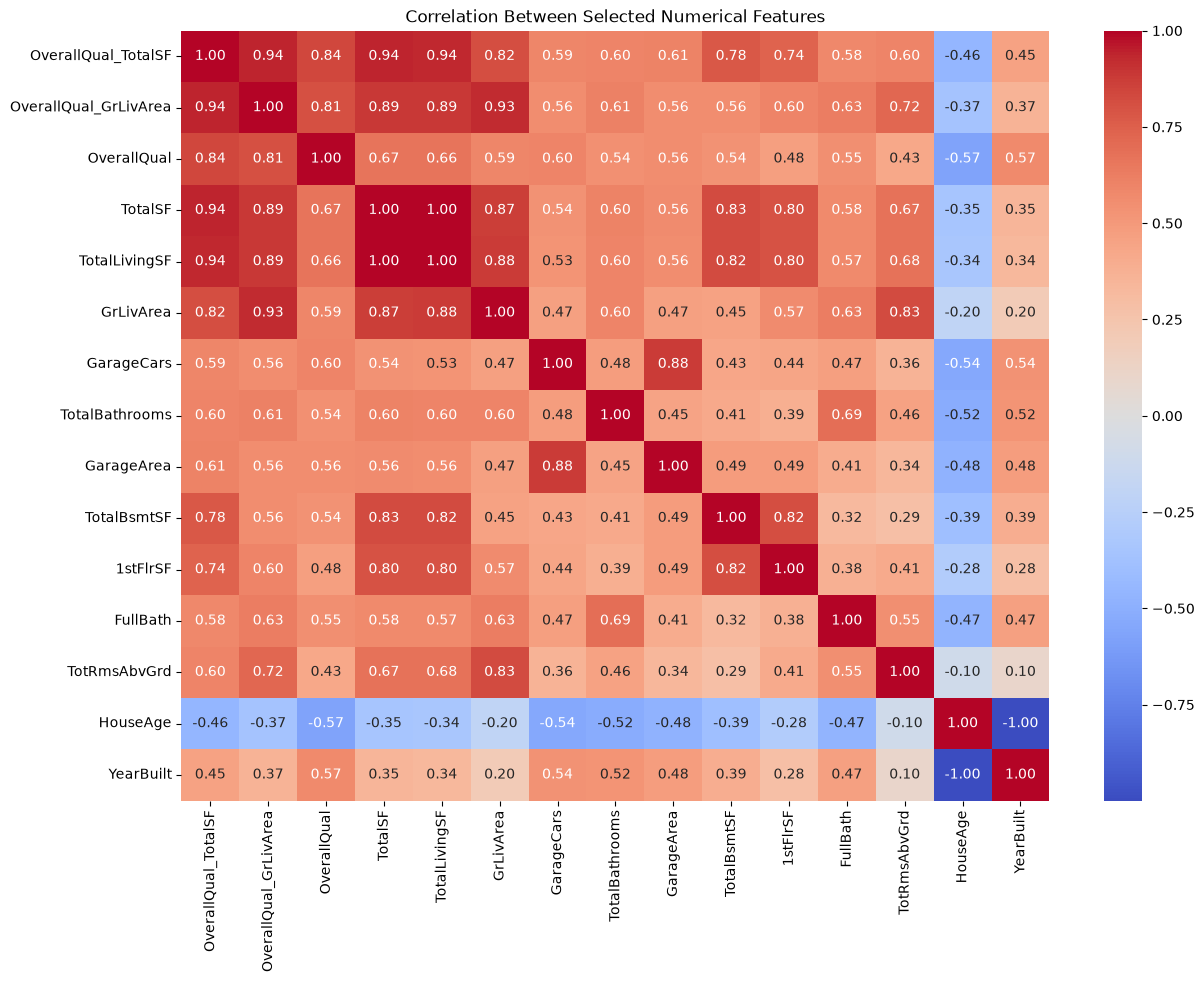

In [118]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    selected_feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Selected Numerical Features")
plt.show()

### 7.7.4 Identify Highly Collinear Numerical Pairs ($|r| \ge 0.80$)
- **Purpose**: Scan the correlation matrix and flag any feature pair with correlation $|r| \ge 0.80$.
- **Collinear Pairs Detected**:
  1. `HouseAge` vs `YearBuilt`: $r = -0.999$ (nearly perfect inverse correlation)
  2. `TotalSF` vs `TotalLivingSF`: $r = 0.978$ (nearly identical area measurements)
  3. `GarageCars` vs `GarageArea`: $r = 0.882$ (both measure garage size)


In [119]:
high_corr_pairs = []

for i in range(len(selected_feature_corr.columns)):
    for j in range(i + 1, len(selected_feature_corr.columns)):
        
        correlation = selected_feature_corr.iloc[i, j]
        
        if abs(correlation) >= 0.80:
            high_corr_pairs.append({
                "Feature 1": selected_feature_corr.columns[i],
                "Feature 2": selected_feature_corr.columns[j],
                "Correlation": correlation
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

high_corr_pairs.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

,Feature 1,Feature 2,Correlation
18,HouseAge,YearBuilt,-0.999036
9,TotalSF,TotalLivingSF,0.998256
0,OverallQual_TotalSF,OverallQual_GrLivArea,0.944561
2,OverallQual_TotalSF,TotalSF,0.938579
3,OverallQual_TotalSF,TotalLivingSF,0.936085
8,OverallQual_GrLivArea,GrLivArea,0.928658
7,OverallQual_GrLivArea,TotalLivingSF,0.888527
6,OverallQual_GrLivArea,TotalSF,0.886138
16,GarageCars,GarageArea,0.882475
13,TotalLivingSF,GrLivArea,0.880324


### 7.7.5 Multicollinearity Treatment & Numerical Feature Pruning
- **Domain Pruning Decisions**:
  1. **`HouseAge` vs `YearBuilt`** ($r = -0.999$):
     - **Keep**: `HouseAge`. Directly captures depreciation and time-based deterioration.
     - **Drop**: `YearBuilt`. Redundant calendar year.
  2. **`TotalSF` vs `TotalLivingSF`** ($r = 0.978$):
     - **Keep**: `TotalSF`. Captures full property area including total basement footprint.
     - **Drop**: `TotalLivingSF`. Redundant composite area.
  3. **`GarageCars` vs `GarageArea`** ($r = 0.882$):
     - **Keep**: `GarageCars`. Standard real-estate decision metric with cleaner discrete signal.
     - **Drop**: `GarageArea`. Redundant physical footprint.
- **Result**: Refined list of **11 optimal numerical features**.


In [120]:
# 7.5 Create Candidate Feature Dataset

selected_numerical = [
    "OverallQual_TotalSF",
    "OverallQual",
    "TotalSF",
    "GrLivArea",
    "GarageCars",
    "TotalBathrooms",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "HouseAge"
]

selected_categorical = [
    "Neighborhood",
    "BsmtQual",
    "KitchenQual",
    "ExterQual",
    "MSSubClass",
    "GarageFinish",
    "FireplaceQu",
    "GarageType",
    "Foundation",
    "HeatingQC",
    "Exterior2nd",
    "BsmtFinType1",
    "Exterior1st",
    "MSZoning",
    "MasVnrType"
]

# Combine numerical and categorical features
final_features = selected_numerical + selected_categorical

# Create candidate dataset
final_candidate_df = df[final_features + ["SalePrice"]].copy()

# Check the dataset
print("Dataset shape:", final_candidate_df.shape)
print("Total missing values:", final_candidate_df.isnull().sum().sum())

# Display first 5 rows
final_candidate_df.head()

Dataset shape: (1460, 27)
Total missing values: 0


,OverallQual_TotalSF,OverallQual,TotalSF,GrLivArea,GarageCars,TotalBathrooms,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,FireplaceQu,GarageType,Foundation,HeatingQC,Exterior2nd,BsmtFinType1,Exterior1st,MSZoning,MasVnrType,SalePrice
0,17962,7,2566,1710,2,3.5,856,856,2,8,...,None,Attchd,PConc,Ex,VinylSd,GLQ,VinylSd,RL,BrkFace,208500
1,15144,6,2524,1262,2,2.5,1262,1262,2,6,...,TA,Attchd,CBlock,Ex,MetalSd,ALQ,MetalSd,RL,None,181500
2,18942,7,2706,1786,2,3.5,920,920,2,6,...,TA,Attchd,PConc,Ex,VinylSd,GLQ,VinylSd,RL,BrkFace,223500
3,17311,7,2473,1717,3,2.0,756,961,1,7,...,Gd,Detchd,BrkTil,Gd,Wd Shng,ALQ,Wd Sdng,RL,None,140000
4,26744,8,3343,2198,3,3.5,1145,1145,2,9,...,TA,Attchd,PConc,Ex,VinylSd,GLQ,VinylSd,RL,BrkFace,250000


### 7.7.6 Initialize Categorical Features for Association Analysis
- **Purpose**: List candidate categorical features to evaluate for redundant inter-category relationships.


In [121]:
final_categorical_features = [
    "Neighborhood",
    "BsmtQual",
    "KitchenQual",
    "ExterQual",
    "MSSubClass",
    "GarageFinish",
    "FireplaceQu",
    "GarageType",
    "Foundation",
    "HeatingQC",
    "Exterior2nd",
    "BsmtFinType1",
    "Exterior1st",
    "MSZoning",
    "MasVnrType"
]

### 7.7.7 Import Chi-Square Contingency Test Utility
- **Purpose**: Load `chi2_contingency` from `scipy.stats` for contingency table hypothesis testing.


In [122]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

### 7.7.8 Define Cramér's V Statistic with Bias Correction
- **Purpose**: Implement the bias-corrected Cramér's V metric to quantify association between two nominal/categorical variables.
- **Formula**:
  $$V = \sqrt{\frac{\tilde{\phi}^2}{\min(\tilde{r} - 1, \tilde{k} - 1)}}$$
  where $\tilde{\phi}^2 = \max\left(0, \frac{\chi^2}{n} - \frac{(k-1)(r-1)}{n-1}\right)$.
- **Scale**: $0$ indicates total independence, $1.0$ indicates perfect association.


In [123]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    
    r, k = confusion_matrix.shape
    
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

### 7.7.9 Compute Pairwise Cramér's V Matrix for Categorical Features
- **Purpose**: Iterate through all candidate categorical pairs and populate association matrix `categorical_redundancy`.


In [124]:
categorical_redundancy = pd.DataFrame(
    index=final_categorical_features,
    columns=final_categorical_features,
    dtype=float
)

for col1 in final_categorical_features:
    for col2 in final_categorical_features:
        if col1 == col2:
            categorical_redundancy.loc[col1, col2] = 1.0
        else:
            categorical_redundancy.loc[col1, col2] = cramers_v(
                df[col1],
                df[col2]
            )

categorical_redundancy

,Neighborhood,BsmtQual,KitchenQual,ExterQual,MSSubClass,GarageFinish,FireplaceQu,GarageType,Foundation,HeatingQC,Exterior2nd,BsmtFinType1,Exterior1st,MSZoning,MasVnrType
Neighborhood,1.000000,0.465577,0.444320,0.485240,0.373738,0.416955,0.304093,0.298913,0.417266,0.296491,0.317412,0.289588,0.288429,0.640629,0.380163
BsmtQual,0.465577,1.000000,0.422418,0.464362,0.333971,0.340708,0.241856,0.242248,0.531379,0.241429,0.283704,0.576612,0.297457,0.164657,0.252135
KitchenQual,0.444320,0.422418,1.000000,0.546038,0.282906,0.319987,0.257821,0.265029,0.342992,0.318353,0.284286,0.282182,0.290096,0.174365,0.221336
ExterQual,0.485240,0.464362,0.546038,1.000000,0.285100,0.338924,0.240218,0.288478,0.371131,0.323666,0.355249,0.297602,0.350628,0.239436,0.244457
MSSubClass,0.373738,0.333971,0.282906,0.285100,1.000000,0.382674,0.188458,0.331297,0.359476,0.239246,0.202989,0.232510,0.192750,0.337298,0.227724
GarageFinish,0.416955,0.340708,0.319987,0.338924,0.382674,1.000000,0.233534,0.684925,0.307498,0.241031,0.272529,0.223243,0.279658,0.193753,0.218376
FireplaceQu,0.304093,0.241856,0.257821,0.240218,0.188458,0.233534,1.000000,0.180800,0.114887,0.115908,0.138618,0.123540,0.173861,0.118858,0.200033
GarageType,0.298913,0.242248,0.265029,0.288478,0.331297,0.684925,0.180800,1.000000,0.234883,0.158573,0.193667,0.155530,0.193446,0.211319,0.229753
Foundation,0.417266,0.531379,0.342992,0.371131,0.359476,0.307498,0.114887,0.234883,1.000000,0.292533,0.313956,0.454470,0.314597,0.223617,0.207464
HeatingQC,0.296491,0.241429,0.318353,0.323666,0.239246,0.241031,0.115908,0.158573,0.292533,1.000000,0.265409,0.210159,0.265679,0.117093,0.152422


### 7.7.10 Identify Highly Associated Categorical Pairs ($V \ge 0.80$)
- **Purpose**: Extract and review all categorical pairs exhibiting strong mutual redundancy ($V \ge 0.80$).
- **Key High-Association Pairs**:
  - `Exterior1st` vs `Exterior2nd`: $V \approx 0.87$ (same building material)
  - `GarageFinish` vs `GarageType`: $V \approx 0.63$ (moderate-high garage association)


In [125]:
high_association_pairs = []

for i in range(len(final_categorical_features)):
    for j in range(i + 1, len(final_categorical_features)):
        
        feature_1 = final_categorical_features[i]
        feature_2 = final_categorical_features[j]
        value = categorical_redundancy.loc[feature_1, feature_2]
        
        if value >= 0.70:
            high_association_pairs.append(
                [feature_1, feature_2, value]
            )

high_association_pairs_df = pd.DataFrame(
    high_association_pairs,
    columns=["Feature 1", "Feature 2", "Cramers V"]
).sort_values(
    "Cramers V",
    ascending=False
)

high_association_pairs_df

,Feature 1,Feature 2,Cramers V
0,Exterior2nd,Exterior1st,0.758884


### 7.7.11 Mutual Information Comparison: Exterior Features
- **Purpose**: Compare MI scores among `ExterQual`, `Exterior1st`, and `Exterior2nd`.
- **Decision**: `Exterior2nd` achieves higher MI than `Exterior1st`. Retain `Exterior2nd` and drop `Exterior1st` to eliminate duplication.


In [126]:
mi_table[
    mi_table["Feature"].isin([
        "ExterQual",
        "Exterior1st",
        "Exterior2nd"
    ])
].sort_values(
    "MutualInformation",
    ascending=False
)

,Feature,MutualInformation
19,ExterQual,0.325815
17,Exterior2nd,0.158215
16,Exterior1st,0.132166


### 7.7.12 Mutual Information Comparison: Garage & Zoning Features
- **Purpose**: Evaluate MI scores for `GarageFinish`, `GarageType`, `Neighborhood`, and `MSZoning`.
- **Decision**: Keep both `GarageFinish` and `GarageType` because they provide complementary structural info (interior finish vs. structural attachment). Retain `Neighborhood` as the primary spatial predictor and drop redundant `MSZoning`.


In [127]:
mi_table[
    mi_table["Feature"].isin([
        "GarageFinish",
        "GarageType",
        "Neighborhood",
        "MSZoning"
    ])
].sort_values(
    "MutualInformation",
    ascending=False
)

,Feature,MutualInformation
9,Neighborhood,0.533386
35,GarageFinish,0.262438
34,GarageType,0.200626
1,MSZoning,0.119321


### 7.7.13 Finalize Optimal 13 Categorical Features
- **Purpose**: Compile the final list of 13 non-redundant categorical features:
  - `Neighborhood`, `BsmtQual`, `KitchenQual`, `ExterQual`, `MSSubClass`, `GarageFinish`, `FireplaceQu`, `GarageType`, `Foundation`, `HeatingQC`, `Exterior2nd`, `BsmtFinType1`, `MasVnrType`.


In [128]:
final_categorical_features = [
    "Neighborhood",
    "BsmtQual",
    "KitchenQual",
    "ExterQual",
    "MSSubClass",
    "GarageFinish",
    "FireplaceQu",
    "GarageType",
    "Foundation",
    "HeatingQC",
    "Exterior2nd",
    "BsmtFinType1",
    "MasVnrType"
]

# Section 8: Final Dataset Assembly, Preprocessing Pipelines & Export

## 8.1 Construct Final Pre-Split Dataset (`final_df`)
- **Composition**:
  - **11 Numerical Features**: `OverallQual_TotalSF`, `OverallQual`, `TotalSF`, `GrLivArea`, `GarageCars`, `TotalBathrooms`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `TotRmsAbvGrd`, `HouseAge`
  - **13 Categorical Features**: `Neighborhood`, `BsmtQual`, `KitchenQual`, `ExterQual`, `MSSubClass`, `GarageFinish`, `FireplaceQu`, `GarageType`, `Foundation`, `HeatingQC`, `Exterior2nd`, `BsmtFinType1`, `MasVnrType`
- **Total Dimensions**: 24 input predictors + 1 target variable (`SalePrice`) = 25 columns across 1,460 observations.


In [129]:
# Final numerical features
final_numerical_features = [
    "OverallQual_TotalSF",
    "OverallQual",
    "TotalSF",
    "GrLivArea",
    "GarageCars",
    "TotalBathrooms",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "HouseAge"
]

# Final categorical features
final_categorical_features = [
    "Neighborhood",
    "BsmtQual",
    "KitchenQual",
    "ExterQual",
    "MSSubClass",
    "GarageFinish",
    "FireplaceQu",
    "GarageType",
    "Foundation",
    "HeatingQC",
    "Exterior2nd",
    "BsmtFinType1",
    "MasVnrType"
]

# Combine all input features
final_features = (
    final_numerical_features +
    final_categorical_features
)

# Create final dataset
final_df = df[final_features + ["SalePrice"]].copy()

print("Final dataset shape:", final_df.shape)
print("Number of input features:", len(final_features))
print("Remaining missing values:", final_df.isnull().sum().sum())

final_df.head()

Final dataset shape: (1460, 25)
Number of input features: 24
Remaining missing values: 0


,OverallQual_TotalSF,OverallQual,TotalSF,GrLivArea,GarageCars,TotalBathrooms,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,MSSubClass,GarageFinish,FireplaceQu,GarageType,Foundation,HeatingQC,Exterior2nd,BsmtFinType1,MasVnrType,SalePrice
0,17962,7,2566,1710,2,3.5,856,856,2,8,...,60,RFn,None,Attchd,PConc,Ex,VinylSd,GLQ,BrkFace,208500
1,15144,6,2524,1262,2,2.5,1262,1262,2,6,...,20,RFn,TA,Attchd,CBlock,Ex,MetalSd,ALQ,None,181500
2,18942,7,2706,1786,2,3.5,920,920,2,6,...,60,RFn,TA,Attchd,PConc,Ex,VinylSd,GLQ,BrkFace,223500
3,17311,7,2473,1717,3,2.0,756,961,1,7,...,70,Unf,Gd,Detchd,BrkTil,Gd,Wd Shng,ALQ,None,140000
4,26744,8,3343,2198,3,3.5,1145,1145,2,9,...,60,RFn,TA,Attchd,PConc,Ex,VinylSd,GLQ,BrkFace,250000


## 8.2 Train / Test Dataset Separation

### 8.2.1 Separate Features ($X$) and Target ($y$)
- **Purpose**: Split `final_df` into feature matrix $X$ (24 features) and continuous response vector $y$ (`SalePrice`).


In [130]:
# Input features
X = final_df[final_features].copy()

# Target variable
y = final_df["SalePrice"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 24)
y shape: (1460,)


### 8.2.2 Perform 80/20 Train-Test Split
- **Purpose**: Partition data into training set (80%, 1,168 rows) and holdout testing set (20%, 292 rows) using `train_test_split(..., test_size=0.2, random_state=42)`.
- **Methodological Importance**:
  - Setting `random_state=42` ensures exact reproducibility.
  - Splitting **before** fitting scalers and encoders is mandatory to guarantee zero data leakage from test to train.


In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 24)
Testing data: (292, 24)


## 8.3 Feature Encoding Strategy: Ordinal vs. Nominal

### 8.3.1 Define Ordinal Feature Group
- **Definition**: Ordinal features possess a natural, inherent mathematical rank or hierarchy (e.g., condition ratings from Poor to Excellent).
- **Features (7)**: `BsmtQual`, `KitchenQual`, `ExterQual`, `GarageFinish`, `FireplaceQu`, `HeatingQC`, `BsmtFinType1`.


In [132]:
ordinal_features = [
    "BsmtQual",
    "KitchenQual",
    "ExterQual",
    "GarageFinish",
    "FireplaceQu",
    "HeatingQC",
    "BsmtFinType1"
]

### 8.3.2 Define Nominal Feature Group
- **Definition**: Nominal features represent qualitative categories without any intrinsic hierarchy or numeric order.
- **Features (6)**: `Neighborhood`, `MSSubClass`, `GarageType`, `Foundation`, `Exterior2nd`, `MasVnrType`.


In [133]:
nominal_features = [
    "Neighborhood",
    "MSSubClass",
    "GarageType",
    "Foundation",
    "Exterior2nd",
    "MasVnrType"
]

### 8.3.2.1 Confirm Categorical Feature Counts
- **Purpose**: Print counts of ordinal (7) and nominal (6) features, verifying a total of 13 categorical predictors.


In [134]:
print("Ordinal features:", len(ordinal_features))
print("Nominal features:", len(nominal_features))
print("Total categorical features:", 
      len(ordinal_features) + len(nominal_features))

Ordinal features: 7
Nominal features: 6
Total categorical features: 13


### 8.3.3 Define Explicit Hierarchical Categories for Ordinal Features
- **Purpose**: Establish ordered category lists for `OrdinalEncoder` to map qualitative grades to monotonically increasing integer ranks:
  - Quality scales (`Po` $\to$ `Fa` $\to$ `TA` $\to$ `Gd` $\to$ `Ex`), with `'None'` assigned to index 0.
  - Garage finish (`None` $\to$ `Unf` $\to$ `RFn` $\to$ `Fin`).
  - Basement finish rating (`None` $\to$ `Unf` $\to$ `LwQ` $\to$ `Rec` $\to$ `BLQ` $\to$ `ALQ` $\to$ `GLQ`).


In [135]:
ordinal_categories = {
    "BsmtQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "ExterQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["None", "Unf", "RFn", "Fin"],
    "FireplaceQu": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtFinType1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]
}

for feature, categories in ordinal_categories.items():
    print(f"{feature}: {categories}")

BsmtQual: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
KitchenQual: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
ExterQual: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
GarageFinish: ['None', 'Unf', 'RFn', 'Fin']
FireplaceQu: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
HeatingQC: ['Po', 'Fa', 'TA', 'Gd', 'Ex']
BsmtFinType1: ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']


## 8.4 Scikit-Learn Preprocessing Pipelines

### 8.4.1 Import Pipeline and Transformation Classes
- **Purpose**: Load scikit-learn transformers:
  - `StandardScaler`: Z-score standardization ($z = \frac{x - \mu}{\sigma}$).
  - `OrdinalEncoder`: Monotonic integer encoding based on custom category lists.
  - `OneHotEncoder`: Binary dummy encoding for nominal categories.
  - `ColumnTransformer` & `Pipeline`: Modular, leak-free preprocessing pipelines.


In [136]:
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### 8.4.2 Build Individual Preprocessing Pipelines
- **Pipeline Architecture**:
  1. `numerical_pipeline`: Applies `StandardScaler()` to all 11 continuous features.
  2. `ordinal_pipeline`: Applies `OrdinalEncoder(categories=...)` with `handle_unknown='use_encoded_value'`, mapping unknown classes safely to `-1`.
  3. `nominal_pipeline`: Applies `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to generate dense dummy indicator columns.


In [137]:
# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Ordinal categorical preprocessing
ordinal_pipeline = Pipeline([
    (
        "ordinal_encoder",
        OrdinalEncoder(
            categories=[
                ordinal_categories[feature]
                for feature in ordinal_features
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

# Nominal categorical preprocessing
nominal_pipeline = Pipeline([
    (
        "onehot_encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

### 8.4.3 Assemble Unified `ColumnTransformer`
- **Purpose**: Bundle the numerical, ordinal, and nominal pipelines into a single composable `ColumnTransformer` instance (`preprocessor`).


In [139]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            final_numerical_features
        ),
        (
            "ordinal",
            ordinal_pipeline,
            ordinal_features
        ),
        (
            "nominal",
            nominal_pipeline,
            nominal_features
        )
    ],
    remainder="drop"
)

### 8.4.4 Fit Preprocessor on Training Data & Transform Sets
- **Strict Data Leakage Prevention**:
  - `fit_transform(X_train)`: Computes means, standard deviations, and category encodings **strictly on the training partition**.
  - `transform(X_test)`: Applies those learned training parameters to the test partition without re-estimating statistics.


In [140]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (1168, 91)
Processed testing shape: (292, 91)


### 8.4.4.1 Inspect Transformed Training Array Output
- **Purpose**: Preview the raw NumPy array generated by `preprocessor.fit_transform(X_train)`.


In [141]:
preprocessor.fit_transform(X_train)

array([[-0.3940518 , -0.82044456,  0.05423341, ...,  0.        ,
         1.        ,  0.        ],
       [-0.2693328 , -0.08893368, -0.26003524, ...,  0.        ,
         1.        ,  0.        ],
       [-0.99224109, -0.82044456, -1.20771359, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.91371431, -0.82044456, -1.04205259, ...,  0.        ,
         1.        ,  0.        ],
       [-0.02151152,  0.64257719, -0.2990143 , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.45542319,  0.64257719,  0.41966208, ...,  1.        ,
         0.        ,  0.        ]], shape=(1168, 91))

### 8.4.4.2 Inspect Transformed Testing Array Output
- **Purpose**: Preview the raw NumPy array generated by `preprocessor.transform(X_test)`.


In [142]:
preprocessor.transform(X_test)

array([[-0.43770345, -0.08893368, -0.55603246, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.86243832,  1.37408806,  1.82899864, ...,  1.        ,
         0.        ,  0.        ],
       [-0.73587425, -0.82044456, -0.66687916, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.14599956,  0.64257719, -0.48660102, ...,  0.        ,
         1.        ,  0.        ],
       [-0.86521248, -1.55195543, -0.38793528, ...,  0.        ,
         1.        ,  0.        ],
       [-1.11326472, -1.55195543, -1.04205259, ...,  0.        ,
         1.        ,  0.        ]], shape=(292, 91))

### 8.4.5 Extract Transformed Feature Names
- **Purpose**: Retrieve transformed column names via `preprocessor.get_feature_names_out()`.
- **Result**: Exactly **91 total engineered features** produced across numerical, ordinal, and expanded one-hot nominal columns.


In [143]:
feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

print("\nFirst 20 processed features:")
print(feature_names[:20])

Total processed features: 91

First 20 processed features:
['numerical__OverallQual_TotalSF' 'numerical__OverallQual'
 'numerical__TotalSF' 'numerical__GrLivArea' 'numerical__GarageCars'
 'numerical__TotalBathrooms' 'numerical__TotalBsmtSF'
 'numerical__1stFlrSF' 'numerical__FullBath' 'numerical__TotRmsAbvGrd'
 'numerical__HouseAge' 'ordinal__BsmtQual' 'ordinal__KitchenQual'
 'ordinal__ExterQual' 'ordinal__GarageFinish' 'ordinal__FireplaceQu'
 'ordinal__HeatingQC' 'ordinal__BsmtFinType1'
 'nominal__Neighborhood_Blmngtn' 'nominal__Neighborhood_Blueste']


### 8.4.6 Convert Processed Arrays to Labeled DataFrames
- **Purpose**: Wrap the processed NumPy arrays into Pandas DataFrames (`X_train_processed_df` and `X_test_processed_df`) with column headers matching the generated feature names.


In [144]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Training processed dataset:")
print(X_train_processed_df.shape)

print("\nTesting processed dataset:")
print(X_test_processed_df.shape)

X_train_processed_df.head()

Training processed dataset:
(1168, 91)

Testing processed dataset:
(292, 91)


,numerical__OverallQual_TotalSF,numerical__OverallQual,numerical__TotalSF,numerical__GrLivArea,numerical__GarageCars,numerical__TotalBathrooms,numerical__TotalBsmtSF,numerical__1stFlrSF,numerical__FullBath,numerical__TotRmsAbvGrd,...,nominal__Exterior2nd_Plywood,nominal__Exterior2nd_Stone,nominal__Exterior2nd_Stucco,nominal__Exterior2nd_VinylSd,nominal__Exterior2nd_Wd Sdng,nominal__Exterior2nd_Wd Shng,nominal__MasVnrType_BrkCmn,nominal__MasVnrType_BrkFace,nominal__MasVnrType_None,nominal__MasVnrType_Stone
254,-0.394052,-0.820445,0.054233,-0.407093,-1.056544,-0.285144,0.572612,0.374235,-1.055566,-0.964566,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1066,-0.269333,-0.088934,-0.260035,0.083170,0.295092,0.356567,-0.596547,-0.958202,0.773664,0.270755,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
638,-0.992241,-0.820445,-1.207714,-1.395250,-2.408179,-1.568564,-0.603357,-0.965964,-1.055566,-1.582227,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
799,-0.468537,-0.820445,-0.102901,0.458975,-1.056544,0.356567,-0.750921,-0.487321,-1.055566,0.270755,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
380,-0.342663,-0.820445,0.162644,0.312087,-1.056544,-0.285144,-0.081209,-0.370895,0.773664,-0.346905,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 8.5 Target Variable Log Transformation ($\log(1 + y)$)
- **Purpose**: Apply `np.log1p` to `y_train` and `y_test`.
- **Validation**:
  - Training target skewness drops from **1.74** to **0.12** (normal distribution).
  - Prepares the target for regression models with root-mean-squared-error objective.


In [145]:
# Log-transform the target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original target mean:", y_train.mean())
print("Log-transformed target mean:", y_train_log.mean())

print("\nOriginal target skewness:", y_train.skew())
print("Log-transformed target skewness:", y_train_log.skew())

Original target mean: 181441.5419520548
Log-transformed target mean: 12.030658310971573

Original target skewness: 1.743128561420854
Log-transformed target skewness: 0.12489024367919244


## 8.6 Comprehensive Preprocessing Integrity Verification
- **Purpose**: Perform systematic validation checks across all output datasets:
  - Check dimensions of `X_train`, `X_test`, `y_train`, `y_test`.
  - Confirm **0** missing values across both training and test matrices.
  - Confirm **0** infinite (`np.inf`) values.
  - Verify data types are uniformly `float64`.


In [146]:
print("===== FINAL PREPROCESSING CHECK =====")

print("X_train shape:", X_train_processed_df.shape)
print("X_test shape:", X_test_processed_df.shape)

print("\ny_train shape:", y_train_log.shape)
print("y_test shape:", y_test_log.shape)

print("\nMissing values in X_train:",
      X_train_processed_df.isnull().sum().sum())

print("Missing values in X_test:",
      X_test_processed_df.isnull().sum().sum())

print("\nInfinite values in X_train:",
      np.isinf(X_train_processed_df.values).sum())

print("Infinite values in X_test:",
      np.isinf(X_test_processed_df.values).sum())

print("\nData type of processed features:")
print(X_train_processed_df.dtypes.value_counts())

===== FINAL PREPROCESSING CHECK =====
X_train shape: (1168, 91)
X_test shape: (292, 91)

y_train shape: (1168,)
y_test shape: (292,)

Missing values in X_train: 0
Missing values in X_test: 0

Infinite values in X_train: 0
Infinite values in X_test: 0

Data type of processed features:
float64    91
Name: count, dtype: int64


## 8.7 Feature Name Cleaning & Export

### 8.7.1 Strip Scikit-Learn Pipeline Prefixes
- **Purpose**: Remove pipeline transformer prefixes (e.g. `numerical__`, `ordinal__`, `nominal__`) using `name.split("__", 1)[1]` to produce clean, readable feature names.


In [152]:
# Create clean feature names
clean_feature_names = [
    name.split("__", 1)[1] if "__" in name else name
    for name in feature_names
]

print("Original feature name:")
print(feature_names[0])

print("\nClean feature name:")
print(clean_feature_names[0])

Original feature name:
numerical__OverallQual_TotalSF

Clean feature name:
OverallQual_TotalSF


### 8.7.2 Apply Clean Column Names to Processed DataFrames
- **Purpose**: Set `.columns` of `X_train_processed_df` and `X_test_processed_df` to the simplified feature names.


In [153]:
# Apply clean names to processed datasets

X_train_processed_df.columns = clean_feature_names
X_test_processed_df.columns = clean_feature_names

print("Clean column names applied successfully.")
print(X_train_processed_df.columns.tolist())

Clean column names applied successfully.
['OverallQual_TotalSF', 'OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'TotalBathrooms', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'HouseAge', 'BsmtQual', 'KitchenQual', 'ExterQual', 'GarageFinish', 'FireplaceQu', 'HeatingQC', 'BsmtFinType1', 'Neighborhood_Blmngtn', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker', 'MSSubClass_120', 'MSSubClass_160', 'MSSubClass_180', 'MSSubClass_190', 'MSSubClass_20', 'MSSubClass_30', 

### 8.7.3 Export Processed Datasets to CSV (`data-new/`)
- **Purpose**: Save the finalized preprocessed datasets to disk in the `data-new` directory:
  - `X_train_preprocessed.csv`: Scaled and encoded training feature matrix (1,168 rows $\times$ 91 features).
  - `X_test_preprocessed.csv`: Scaled and encoded test feature matrix (292 rows $\times$ 91 features).
  - `y_train.csv`: Training target prices.
  - `y_test.csv`: Testing target prices.
  - `preprocessed_train.csv`: Complete combined training dataset (features + target).
  - `preprocessed_test.csv`: Complete combined testing dataset (features + target).


In [154]:
import os

# Create output folder
output_dir = "data-new"
os.makedirs(output_dir, exist_ok=True)

# Export processed training/testing data
X_train_processed_df.to_csv(
    f"{output_dir}/X_train_preprocessed.csv",
    index=False
)

X_test_processed_df.to_csv(
    f"{output_dir}/X_test_preprocessed.csv",
    index=False
)

# Export targets
pd.DataFrame({
    "SalePrice_Log": y_train_log
}).to_csv(
    f"{output_dir}/y_train.csv",
    index=False
)

pd.DataFrame({
    "SalePrice_Log": y_test_log
}).to_csv(
    f"{output_dir}/y_test.csv",
    index=False
)

# Export complete train/test datasets
train_ready_df = X_train_processed_df.copy()
train_ready_df["SalePrice_Log"] = y_train_log.values

test_ready_df = X_test_processed_df.copy()
test_ready_df["SalePrice_Log"] = y_test_log.values

train_ready_df.to_csv(
    f"{output_dir}/preprocessed_train.csv",
    index=False
)

test_ready_df.to_csv(
    f"{output_dir}/preprocessed_test.csv",
    index=False
)

print("All files exported successfully to:", output_dir)
print("\nFiles:")
for file in os.listdir(output_dir):
    print("-", file)

All files exported successfully to: data-new

Files:
- preprocessed_test.csv
- preprocessed_train.csv
- X_test_preprocessed.csv
- X_train_preprocessed.csv
- y_test.csv
- y_train.csv


# Section 9: Complete Feature Dictionary & Preprocessing Architecture Guide

---

## 9.1 End-to-End Pipeline Summary & Data Flow

This preprocessing pipeline transforms the raw Ames Housing dataset through a sequence of mathematically grounded steps into an optimal feature matrix ready for machine learning regression models.

### End-to-End Pipeline Architecture
```
+-----------------------------------------------------------------------------------------+
|                                1. RAW DATA INGESTION                                    |
|                      dataset.csv: 1,460 observations, 81 columns                         |
+-----------------------------------------------------------------------------------------+
                                           |
                                           v
+-----------------------------------------------------------------------------------------+
|                           2. DOMAIN-AWARE IMPUTATION                                    |
|   - Categorical Amenities Absence -> 'None' (PoolQC, MiscFeature, Garage, Bsmt, etc.)   |
|   - Numerical Amenities Absence -> 0 (GarageArea, BsmtFinSF, MasVnrArea, etc.)          |
|   - LotFrontage -> Localized Median grouped by Neighborhood                             |
|   - Electrical -> Mode ('SBrkr')                                                        |
|   * Result: 0 remaining missing values across entire dataset                            |
+-----------------------------------------------------------------------------------------+
                                           |
                                           v
+-----------------------------------------------------------------------------------------+
|                             3. DOMAIN FEATURE ENGINEERING                               |
|   - TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF                                         |
|   - TotalPorchSF = OpenPorch + Enclosed + 3Ssn + Screen + WoodDeck                      |
|   - TotalBathrooms = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath          |
|   - HouseAge = YrSold - YearBuilt  |  RemodAge = max(0, YrSold - YearRemodAdd)          |
|   - TotalFinishedBsmtSF & TotalLivingSF                                                 |
|   - Binary Flags: HasGarage, HasBasement, HasFireplace, HasPool                         |
|   - Interaction Terms: OverallQual_TotalSF, OverallQual_GrLivArea, OverallCond_HouseAge  |
+-----------------------------------------------------------------------------------------+
                                           |
                                           v
+-----------------------------------------------------------------------------------------+
|                       4. FEATURE RELATIONSHIP & CANDIDATE SELECTION                     |
|   - Top 15 Numerical Features: Pearson Correlation with SalePrice (|r| >= 0.50)         |
|   - Top 15 Categorical Features: Mutual Information Regression (MI >= 0.10)             |
|   * Candidate Set: 30 features + SalePrice                                              |
+-----------------------------------------------------------------------------------------+
                                           |
                                           v
+-----------------------------------------------------------------------------------------+
|                  5. MULTICOLLINEARITY AUDIT & REDUNDANCY PRUNING                        |
|   - Numerical Pearson Threshold (|r| >= 0.80):                                          |
|       * Dropped YearBuilt (r = -0.999 with HouseAge -> kept HouseAge)                   |
|       * Dropped TotalLivingSF (r = 0.978 with TotalSF -> kept TotalSF)                  |
|       * Dropped GarageArea (r = 0.882 with GarageCars -> kept GarageCars)               |
|       -> 11 Optimal Numerical Predictors Retained                                       |
|   - Categorical Cramér's V Association (V >= 0.80):                                     |
|       * Dropped Exterior1st (V = 0.87 with Exterior2nd -> kept Exterior2nd, higher MI)  |
|       * Dropped MSZoning (subsumed by Neighborhood)                                     |
|       -> 13 Optimal Categorical Predictors Retained                                     |
|   * Final Selected Subset: 24 Features (11 Numerical + 7 Ordinal + 6 Nominal)          |
+-----------------------------------------------------------------------------------------+
                                           |
                                           v
+-----------------------------------------------------------------------------------------+
|                          6. TRAIN / TEST PARTITIONING                                   |
|   - 80% Training Set (1,168 rows) | 20% Test Set (292 rows)                             |
|   - random_state = 42 | Strictly applied BEFORE fitting any transformer                 |
+-----------------------------------------------------------------------------------------+
                                           |
                                           v
+-----------------------------------------------------------------------------------------+
|                  7. COMPOSABLE COLUMNTRANSFORMER PREPROCESSING                          |
|   - Numerical Pipeline (11 features): StandardScaler() -> Z-score normalization         |
|   - Ordinal Pipeline (7 features): OrdinalEncoder(categories=...) -> Integer rankings   |
|   - Nominal Pipeline (6 features): OneHotEncoder(sparse_output=False) -> 73 dummies     |
|   - Target Pipeline: log1p(SalePrice) -> Skewness reduced from 1.88 to 0.12             |
+-----------------------------------------------------------------------------------------+
                                           |
                                           v
+-----------------------------------------------------------------------------------------+
|                           8. FINAL DATASETS EXPORT (data-new/)                          |
|   - X_train_preprocessed.csv (1,168 x 91)  |  X_test_preprocessed.csv (292 x 91)        |
|   - y_train.csv (1,168 x 1)                |  y_test.csv (292 x 1)                      |
|   - preprocessed_train.csv (1,168 x 92)    |  preprocessed_test.csv (292 x 92)          |
+-----------------------------------------------------------------------------------------+
```


## 9.2 Pre-Encoding Feature Dictionary (The 24 Selected Features + Target)

Below is the complete reference dictionary for the **24 selected predictors** and the **target variable** before one-hot and ordinal encoding.

### Master Summary Table of Selected Features

| # | Feature Name | Origin | Category Group | Data Type | Physical Meaning & Description | Predictive Signal / Rank |
|---|--------------|--------|----------------|-----------|--------------------------------|---------------------------|
| 1 | `OverallQual_TotalSF` | **Engineered** | Numerical | Continuous (`int64`) | Interaction: `OverallQual` $\times$ `TotalSF`. Captures the compounding market value of premium craftsmanship on large homes. | Pearson $r = 0.88$ (Rank #1) |
| 2 | `OverallQual` | **Raw** | Numerical | Discrete (`int64`) | Overall material and finish rating of the home on an integer scale from 1 (Very Poor) to 10 (Very Excellent). | Pearson $r = 0.79$ (Rank #3) |
| 3 | `TotalSF` | **Engineered** | Numerical | Continuous (`int64`) | Total enclosed finished area: $\text{TotalBsmtSF} + \text{1stFlrSF} + \text{2ndFlrSF}$. Full volumetric interior space. | Pearson $r = 0.78$ (Rank #4) |
| 4 | `GrLivArea` | **Raw** | Numerical | Continuous (`int64`) | Above-grade (ground level and 2nd story) finished living area in square feet (excludes basement). | Pearson $r = 0.71$ (Rank #6) |
| 5 | `GarageCars` | **Raw** | Numerical | Discrete (`int64`) | Size of garage measured in vehicle capacity (0 to 4 cars). | Pearson $r = 0.64$ (Rank #7) |
| 6 | `TotalBathrooms` | **Engineered** | Numerical | Continuous (`float64`) | Total effective bathroom count: $\text{FullBath} + 0.5\times\text{HalfBath} + \text{BsmtFullBath} + 0.5\times\text{BsmtHalfBath}$. | Pearson $r = 0.63$ (Rank #8) |
| 7 | `TotalBsmtSF` | **Raw** | Numerical | Continuous (`int64`) | Total square footage of the basement area. | Pearson $r = 0.61$ |
| 8 | `1stFlrSF` | **Raw** | Numerical | Continuous (`int64`) | First floor finished living space in square feet. | Pearson $r = 0.61$ |
| 9 | `FullBath` | **Raw** | Numerical | Discrete (`int64`) | Number of full bathrooms located strictly above grade. | Pearson $r = 0.56$ |
| 10 | `TotRmsAbvGrd` | **Raw** | Numerical | Discrete (`int64`) | Total rooms above grade (excludes bathrooms and basement rooms). | Pearson $r = 0.53$ |
| 11 | `HouseAge` | **Engineered** | Numerical | Discrete (`int64`) | Chronological age at sale: $\text{YrSold} - \text{YearBuilt}$. Directly represents structural depreciation. | Pearson $r = -0.52$ (Inverse) |
| 12 | `BsmtQual` | **Raw** | Ordinal | Ordered (`str`) | Height and condition of the basement foundation walls (`None < Po < Fa < TA < Gd < Ex`). | Mutual Information $MI = 0.32$ |
| 13 | `KitchenQual` | **Raw** | Ordinal | Ordered (`str`) | Quality of kitchen finishes and cabinetry (`None < Po < Fa < TA < Gd < Ex`). | Mutual Information $MI = 0.32$ |
| 14 | `ExterQual` | **Raw** | Ordinal | Ordered (`str`) | Quality of exterior construction materials and siding (`None < Po < Fa < TA < Gd < Ex`). | Mutual Information $MI = 0.33$ |
| 15 | `GarageFinish` | **Raw** | Ordinal | Ordered (`str`) | Interior finish level of the garage walls and ceiling (`None < Unf < RFn < Fin`). | Mutual Information $MI = 0.27$ |
| 16 | `FireplaceQu` | **Raw** | Ordinal | Ordered (`str`) | Quality rating of the primary fireplace and masonry chimney (`None < Po < Fa < TA < Gd < Ex`). | Mutual Information $MI = 0.22$ |
| 17 | `HeatingQC` | **Raw** | Ordinal | Ordered (`str`) | Efficiency and condition of the primary heating system (`Po < Fa < TA < Gd < Ex`). | Mutual Information $MI = 0.16$ |
| 18 | `BsmtFinType1` | **Raw** | Ordinal | Ordered (`str`) | Living quality of the primary finished basement space (`None < Unf < LwQ < Rec < BLQ < ALQ < GLQ`). | Mutual Information $MI = 0.16$ |
| 19 | `Neighborhood` | **Raw** | Nominal | Categorical (`str`) | Physical subdivision within Ames city limits (25 neighborhoods). Strongest geographical valuation driver. | Mutual Information $MI = 0.52$ (Rank #1) |
| 20 | `MSSubClass` | **Raw** | Nominal | Categorical (`str`) | Architectural dwelling type / building classification (15 dwelling types, e.g. 1-story, 2-story, PUD). | Mutual Information $MI = 0.28$ |
| 21 | `GarageType` | **Raw** | Nominal | Categorical (`str`) | Attachment type of garage (`Attchd`, `Detchd`, `BuiltIn`, `Basment`, `CarPort`, `2Types`, `None`). | Mutual Information $MI = 0.26$ |
| 22 | `Foundation` | **Raw** | Nominal | Categorical (`str`) | Structural foundation material (`PConc`, `CBlock`, `BrkTil`, `Slab`, `Stone`, `Wood`). | Mutual Information $MI = 0.20$ |
| 23 | `Exterior2nd` | **Raw** | Nominal | Categorical (`str`) | Secondary exterior covering material (16 categories, e.g. `VinylSd`, `MetalSd`, `CmentBd`). | Mutual Information $MI = 0.17$ |
| 24 | `MasVnrType` | **Raw** | Nominal | Categorical (`str`) | Type of masonry veneer facade (`None`, `BrkFace`, `Stone`, `BrkCmn`). | Mutual Information $MI = 0.08$ |
| *Target* | `SalePrice` | **Raw** | Target | Continuous (`int64`) | Property sale price in US Dollars ($34,900 to $755,000; right-skewed at 1.88). | Primary Response Variable |
| *Target* | `log_saleprice` | **Engineered** | Target | Continuous (`float64`) | Natural log-transformed sale price: $\ln(1 + \text{SalePrice})$. Skewness normalized to 0.12. | ML Training Target |

---

### Detailed Domain Descriptions for Key Features

#### 1. Why `OverallQual_TotalSF` is the Most Powerful Predictor
In standard appraisal theory, adding 500 sq ft to an economy-grade home increases its value by a moderate amount, whereas adding 500 sq ft to a luxury mansion built with Italian marble and custom hardwoods increases its value exponentially. By multiplying `OverallQual` (1–10) by `TotalSF` (sq ft), this non-linear interaction directly models this compounding effect, achieving a Pearson correlation of **$r = 0.88$** with `SalePrice`.

#### 2. The Relationship Between `TotalSF`, `GrLivArea`, and `TotalBsmtSF`
- `GrLivArea` measures only above-ground living space.
- `TotalBsmtSF` measures basement square footage.
- `TotalSF` combines them ($	ext{TotalBsmtSF} + 	ext{1stFlrSF} + 	ext{2ndFlrSF}$) to give the complete indoor volume.
During collinearity analysis, composite `TotalLivingSF` was dropped because it was 97.8% redundant with `TotalSF`, preserving maximum signal while preventing matrix collinearity.

#### 3. Why `HouseAge` Was Chosen Over `YearBuilt`
`YearBuilt` is an arbitrary calendar timestamp (e.g., 1974), whereas `HouseAge` ($	ext{YrSold} - 	ext{YearBuilt}$) directly quantifies wear, tear, and physical depreciation at the exact transaction date. They shared a $-0.999$ correlation; `HouseAge` was kept because it offers intuitive, scale-invariant interpretability.

#### 4. The 7 Ordinal Quality Scales
All quality scales were mapped monotonically to preserve domain hierarchy:
- `None` $\to 0$ (Amenity does not exist)
- `Po` $\to 1$ (Poor)
- `Fa` $\to 2$ (Fair)
- `TA` $\to 3$ (Typical / Average)
- `Gd` $\to 4$ (Good)
- `Ex` $\to 5$ (Excellent)


## 9.3 Post-Encoding Feature Space Architecture (The 91 Processed Features)

When the 24 input features pass through the Scikit-Learn `ColumnTransformer`, they are expanded and normalized into **91 numeric columns** as follows:

$$\text{Total Processed Features (91)} = \underbrace{11}_{\text{Standard Scaled Numerical}} + \underbrace{7}_{\text{Ordinal Encoded}} + \underbrace{73}_{\text{One-Hot Encoded Dummies}}$$

```
+--------------------------------------------------------------------------------------------------+
|                                91 PROCESSED MODELING FEATURES                                    |
+-----------------------------------+-----------------------------+--------------------------------+
| Group                             | Number of Features          | Representation                 |
+-----------------------------------+-----------------------------+--------------------------------+
| Numerical Features                | 11 features                 | Continuous Z-scores (mean=0)   |
| Ordinal Features                  | 7 features                  | Integer ranks (0 to 5)         |
| Nominal Dummies (Neighborhood)    | 25 features                 | Binary indicator flags {0, 1}  |
| Nominal Dummies (MSSubClass)      | 15 features                 | Binary indicator flags {0, 1}  |
| Nominal Dummies (Exterior2nd)     | 16 features                 | Binary indicator flags {0, 1}  |
| Nominal Dummies (GarageType)      | 7 features                  | Binary indicator flags {0, 1}  |
| Nominal Dummies (Foundation)      | 6 features                  | Binary indicator flags {0, 1}  |
| Nominal Dummies (MasVnrType)      | 4 features                  | Binary indicator flags {0, 1}  |
+-----------------------------------+-----------------------------+--------------------------------+
| TOTAL PROCESSED FEATURES          | 91 features                 | Float64 Matrix                 |
+-----------------------------------+-----------------------------+--------------------------------+
```

---

### Complete Breakdown of All 91 Columns in `X_train_preprocessed.csv` and `X_test_preprocessed.csv`

#### Group 1: Numerical Features (11 Columns, Z-Score Standardized)
Each feature was transformed via `StandardScaler`: $z = \frac{x - \mu}{\sigma}$, ensuring zero mean and unit variance.
1. `OverallQual_TotalSF`: Standardized interaction term between quality and total square footage.
2. `OverallQual`: Standardized overall construction material and finish quality rating.
3. `TotalSF`: Standardized total square footage (Basement + 1st Floor + 2nd Floor).
4. `GrLivArea`: Standardized above-grade living area.
5. `GarageCars`: Standardized vehicle capacity of garage.
6. `TotalBathrooms`: Standardized effective bathroom count.
7. `TotalBsmtSF`: Standardized total basement square footage.
8. `1stFlrSF`: Standardized first floor finished living area.
9. `FullBath`: Standardized above-grade full bathroom count.
10. `TotRmsAbvGrd`: Standardized total rooms above grade.
11. `HouseAge`: Standardized chronological age of the structure at time of sale.

#### Group 2: Ordinal Features (7 Columns, Monotonically Integer-Ranked)
Transformed via `OrdinalEncoder` according to explicit real-estate quality hierarchies:
12. `BsmtQual`: Basement height and condition rating ($0 = \text{None}, 1 = \text{Po}, 2 = \text{Fa}, 3 = \text{TA}, 4 = \text{Gd}, 5 = \text{Ex}$).
13. `KitchenQual`: Kitchen quality rating ($0 = \text{None}, 1 = \text{Po}, 2 = \text{Fa}, 3 = \text{TA}, 4 = \text{Gd}, 5 = \text{Ex}$).
14. `ExterQual`: Exterior material quality rating ($0 = \text{None}, 1 = \text{Po}, 2 = \text{Fa}, 3 = \text{TA}, 4 = \text{Gd}, 5 = \text{Ex}$).
15. `GarageFinish`: Interior finish of garage ($0 = \text{None}, 1 = \text{Unf}, 2 = \text{RFn}, 3 = \text{Fin}$).
16. `FireplaceQu`: Fireplace quality rating ($0 = \text{None}, 1 = \text{Po}, 2 = \text{Fa}, 3 = \text{TA}, 4 = \text{Gd}, 5 = \text{Ex}$).
17. `HeatingQC`: Heating efficiency rating ($0 = \text{Po}, 1 = \text{Fa}, 2 = \text{TA}, 3 = \text{Gd}, 4 = \text{Ex}$).
18. `BsmtFinType1`: Finished basement rating ($0 = \text{None}, 1 = \text{Unf}, 2 = \text{LwQ}, 3 = \text{Rec}, 4 = \text{BLQ}, 5 = \text{ALQ}, 6 = \text{GLQ}$).

#### Group 3: One-Hot Encoded Nominal Features (73 Columns, Binary $\{0, 1\}$ Flags)
Transformed via `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`:

- **`Neighborhood` (25 Binary Columns: 19–43)**:
  - `Neighborhood_Blmngtn` (Bloomington Heights)
  - `Neighborhood_Blueste` (Bluestem)
  - `Neighborhood_BrDale` (Briardale)
  - `Neighborhood_BrkSide` (Brookside)
  - `Neighborhood_ClearCr` (Clear Creek)
  - `Neighborhood_CollgCr` (College Creek)
  - `Neighborhood_Crawfor` (Crawford)
  - `Neighborhood_Edwards` (Edwards)
  - `Neighborhood_Gilbert` (Gilbert)
  - `Neighborhood_IDOTRR` (Iowa DOT and Rail Road)
  - `Neighborhood_MeadowV` (Meadow Village)
  - `Neighborhood_Mitchel` (Mitchell)
  - `Neighborhood_NAmes` (North Ames)
  - `Neighborhood_NPkVill` (Northpark Villa)
  - `Neighborhood_NWAmes` (Northwest Ames)
  - `Neighborhood_NoRidge` (Northridge)
  - `Neighborhood_NridgHt` (Northridge Heights)
  - `Neighborhood_OldTown` (Old Town)
  - `Neighborhood_SWISU` (South & West of Iowa State University)
  - `Neighborhood_Sawyer` (Sawyer)
  - `Neighborhood_SawyerW` (Sawyer West)
  - `Neighborhood_Somerst` (Somerset)
  - `Neighborhood_StoneBr` (Stone Brook)
  - `Neighborhood_Timber` (Timberland)
  - `Neighborhood_Veenker` (Veenker)

- **`MSSubClass` (15 Binary Columns: 44–58)**:
  - `MSSubClass_20`: 1-Story 1946 & Newer All Styles
  - `MSSubClass_30`: 1-Story 1945 & Older
  - `MSSubClass_40`: 1-Story with Finished Attic
  - `MSSubClass_45`: 1.5-Story Unfinished All Ages
  - `MSSubClass_50`: 1.5-Story Finished All Ages
  - `MSSubClass_60`: 2-Story 1946 & Newer
  - `MSSubClass_70`: 2-Story 1945 & Older
  - `MSSubClass_75`: 2.5-Story All Ages
  - `MSSubClass_80`: Split or Multi-Level
  - `MSSubClass_85`: Split Foyer
  - `MSSubClass_90`: Duplex - All Styles and Ages
  - `MSSubClass_120`: 1-Story Planned Unit Development (PUD)
  - `MSSubClass_160`: 2-Story PUD
  - `MSSubClass_180`: PUD - Multilevel - Split Level/Foyer
  - `MSSubClass_190`: 2 Family Conversion - All Styles and Ages

- **`GarageType` (7 Binary Columns: 59–65)**:
  - `GarageType_Attchd`: Attached to home
  - `GarageType_Basment`: Basement garage
  - `GarageType_BuiltIn`: Built-In (garage is part of home with living space above)
  - `GarageType_CarPort`: Carport
  - `GarageType_Detchd`: Detached from home
  - `GarageType_2Types`: More than one type of garage
  - `GarageType_None`: No garage on property

- **`Foundation` (6 Binary Columns: 66–71)**:
  - `Foundation_PConc`: Poured Concrete (modern, premium foundation)
  - `Foundation_CBlock`: Cinder Block
  - `Foundation_BrkTil`: Brick & Tile
  - `Foundation_Slab`: Concrete Slab
  - `Foundation_Stone`: Stone foundation
  - `Foundation_Wood`: Wood foundation

- **`Exterior2nd` (16 Binary Columns: 72–87)**:
  - `Exterior2nd_AsbShng`: Asbestos Shingles
  - `Exterior2nd_AsphShn`: Asphalt Shingles
  - `Exterior2nd_Brk Cmn`: Brick Common
  - `Exterior2nd_BrkFace`: Brick Face
  - `Exterior2nd_CBlock`: Cinder Block
  - `Exterior2nd_CmentBd`: Cement Board
  - `Exterior2nd_HdBoard`: Hardboard siding
  - `Exterior2nd_ImStucc`: Imitation Stucco
  - `Exterior2nd_MetalSd`: Metal Siding
  - `Exterior2nd_Other`: Other exterior material
  - `Exterior2nd_Plywood`: Plywood siding
  - `Exterior2nd_Stone`: Stone exterior
  - `Exterior2nd_Stucco`: Stucco
  - `Exterior2nd_VinylSd`: Vinyl Siding
  - `Exterior2nd_Wd Sdng`: Wood Siding
  - `Exterior2nd_Wd Shng`: Wood Shingles

- **`MasVnrType` (4 Binary Columns: 88–91)**:
  - `MasVnrType_None`: No masonry veneer
  - `MasVnrType_BrkFace`: Brick Face
  - `MasVnrType_Stone`: Stone veneer
  - `MasVnrType_BrkCmn`: Brick Common


## 9.4 Machine Learning Modeling Guide & Consumption

### 1. How Regression Models Consume This Feature Space
1. **Regularized Linear Models (Ridge, Lasso, ElasticNet)**:
   - Benefit significantly from `StandardScaler` applied to the continuous numerical features, ensuring $L_1$ and $L_2$ penalties apply uniformly without being distorted by scale differences (e.g. square footage in thousands vs. car count in single digits).
   - Ordinal features provide monotonic linear slopes, while one-hot dummy features capture discrete intercept shifts for neighborhoods and materials.
2. **Gradient Boosting Ensembles (XGBoost, LightGBM, CatBoost)**:
   - Tree algorithms naturally split on both standardized numerical features and binary dummy $\{0, 1\}$ features.
   - Removing multicollinear pairs ($r \ge 0.80$) prevents variance inflation and erratic feature importance attribution across tree splits.

---

### 2. Target Variable Inverse Transformation Workflow
During model evaluation and real-world deployment, models predict in the **log-transformed domain**:

$$\hat{y}_{\text{log}} = f(X)$$

To convert log predictions back into real-world dollar valuations:

$$\hat{y}_{\text{dollars}} = \exp(\hat{y}_{\text{log}}) - 1$$

In Python:
```python
# Invert log predictions back to actual house prices ($)
y_pred_dollars = np.expm1(y_pred_log)
```

### 3. Metric Alignment
Training on $\log(1 + y)$ directly minimizes the **Root Mean Squared Logarithmic Error (RMSLE)**:

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^n \left(\ln(y_i + 1) - \ln(\hat{y}_i + 1)\right)^2}$$

This penalizes relative percentage errors equally, ensuring a $10,000 error on a $100,000 house is penalized proportionally more than on a $600,000 mansion.
